### Preparing and analysing time series data

In [228]:
# Get the libraries and set random seed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from scipy import signal
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.holtwinters import ExponentialSmoothing 
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL

np.random.seed(42)

#### Data manipulation

In [229]:
# Get the data

db_offshore = pd.read_csv('/Users/kirillkharlashkin/Documents/Hertie Github repos/Watts-next/data/final_offshore_data_2017_2025.csv')
db_onshore = pd.read_csv('/Users/kirillkharlashkin/Documents/Hertie Github repos/Watts-next/data/final_onshore_data_2017_2025.csv')

In [230]:
# Drop excessive columns that are not need for the analysis

db_offshore = db_offshore.drop(columns=['emission', 'emissionfactor', 'year_mon_day', 'full_datetime'])
db_onshore = db_onshore.drop(columns=['emission', 'emissionfactor', 'year_mon_day', 'full_datetime'])

In [231]:
# Write the function to engineer datetime features

def transform_datetime_features(df, correct_days_column='correct_days', start_date='2017-01-01'):

    df = df.copy()
    
    # Split into 'date' and 'hour'
    df[['date', 'hour']] = df[correct_days_column].str.rsplit('-', n=1, expand=True)
    
    # Create datetime column
    df['datetime'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['hour'].astype(int) - 1, unit='H')
    
    # Extract month
    df['month'] = df['datetime'].dt.to_period('M').astype(str)
    
    # Calculate week number
    start_date = pd.Timestamp(start_date)
    df['week_number'] = ((df['datetime'] - start_date).dt.days // 7) + 1
    
    return df

In [232]:
# Apply the function to both datasets

db_offshore = transform_datetime_features(db_offshore)
db_onshore = transform_datetime_features(db_onshore)

/var/folders/6x/v5640c0d6tjd96p_48y5_sy40000gn/T/ipykernel_5199/1621329718.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df['datetime'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['hour'].astype(int) - 1, unit='H')
/var/folders/6x/v5640c0d6tjd96p_48y5_sy40000gn/T/ipykernel_5199/1621329718.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df['datetime'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['hour'].astype(int) - 1, unit='H')


In [233]:
# Drop datetime 2025-01-01 and set datetime as index
db_offshore = db_offshore[db_offshore['datetime'] != '2025-01-01']
db_onshore = db_onshore[db_onshore['datetime'] != '2025-01-01']

db_offshore.set_index('datetime', inplace=True)
db_onshore.set_index('datetime', inplace=True)

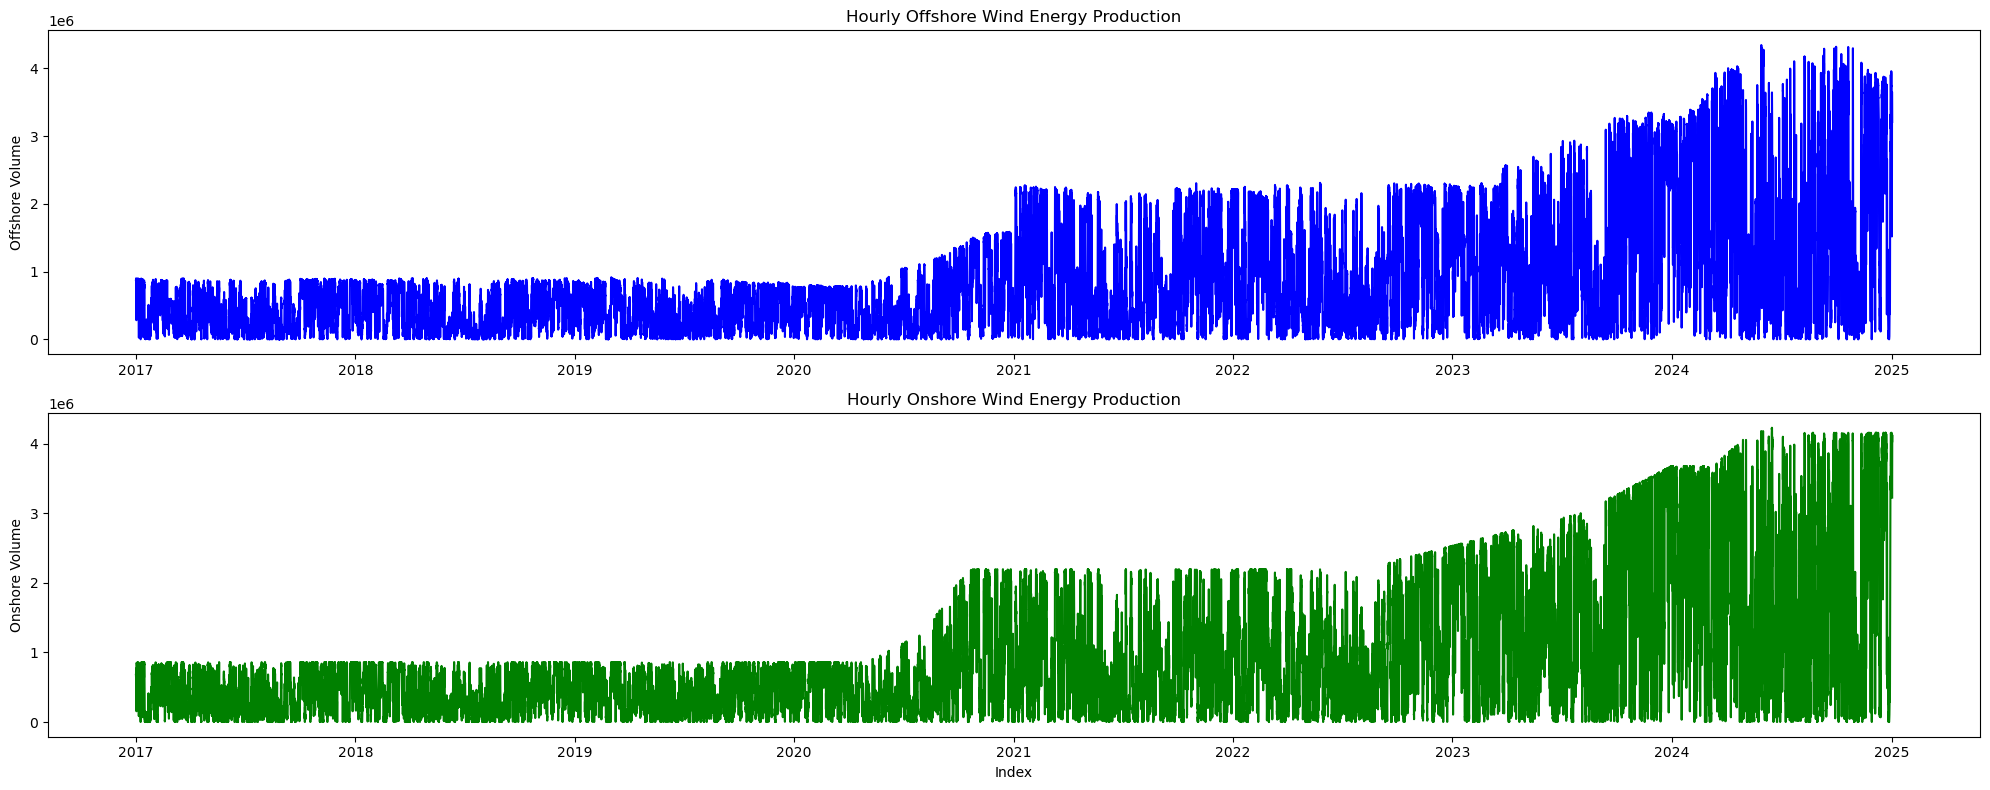

In [234]:
# Make two plots with the label variable

plt.figure(figsize=(20, 8))

# Offshore
plt.subplot(2, 1, 1)  # (nrows=2, ncols=1, index=1)
plt.plot(db_offshore.index, db_offshore['volume'], color='blue')
plt.title('Hourly Offshore Wind Energy Production')
plt.ylabel('Offshore Volume')

# Onshore
plt.subplot(2, 1, 2)  # (nrows=2, ncols=1, index=2)
plt.plot(db_onshore.index, db_onshore['volume'], color='green')
plt.title('Hourly Onshore Wind Energy Production')
plt.ylabel('Onshore Volume')
plt.xlabel('Index')

plt.tight_layout()
plt.show()

#### Time series analysis

##### Seasonal decomposition

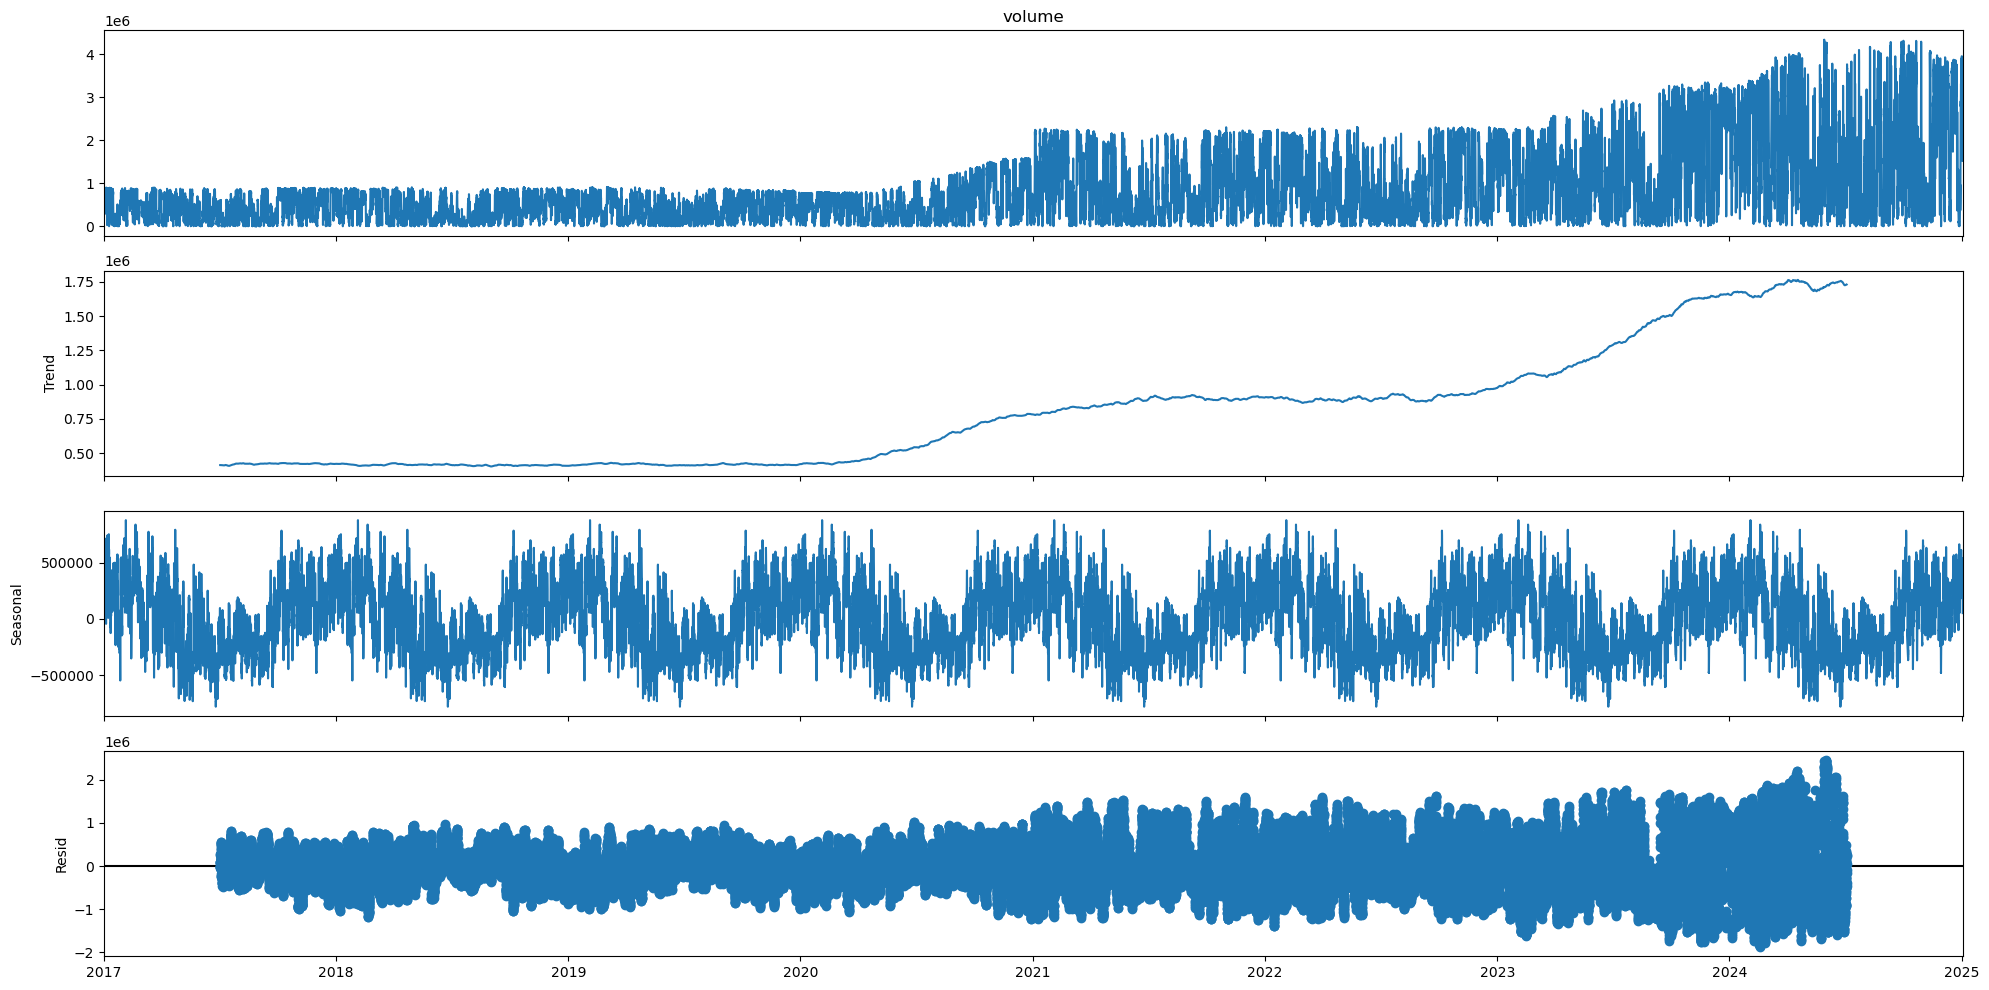

In [235]:
# Check for trend and seasonality for offshore data

decomposition_offshore = seasonal_decompose(db_offshore['volume'], 
                                 model='additive', 
                                 period=8760)  # Annual seasonality
fig = decomposition_offshore.plot()
fig.set_size_inches(20, 10)
plt.tight_layout()
plt.show()

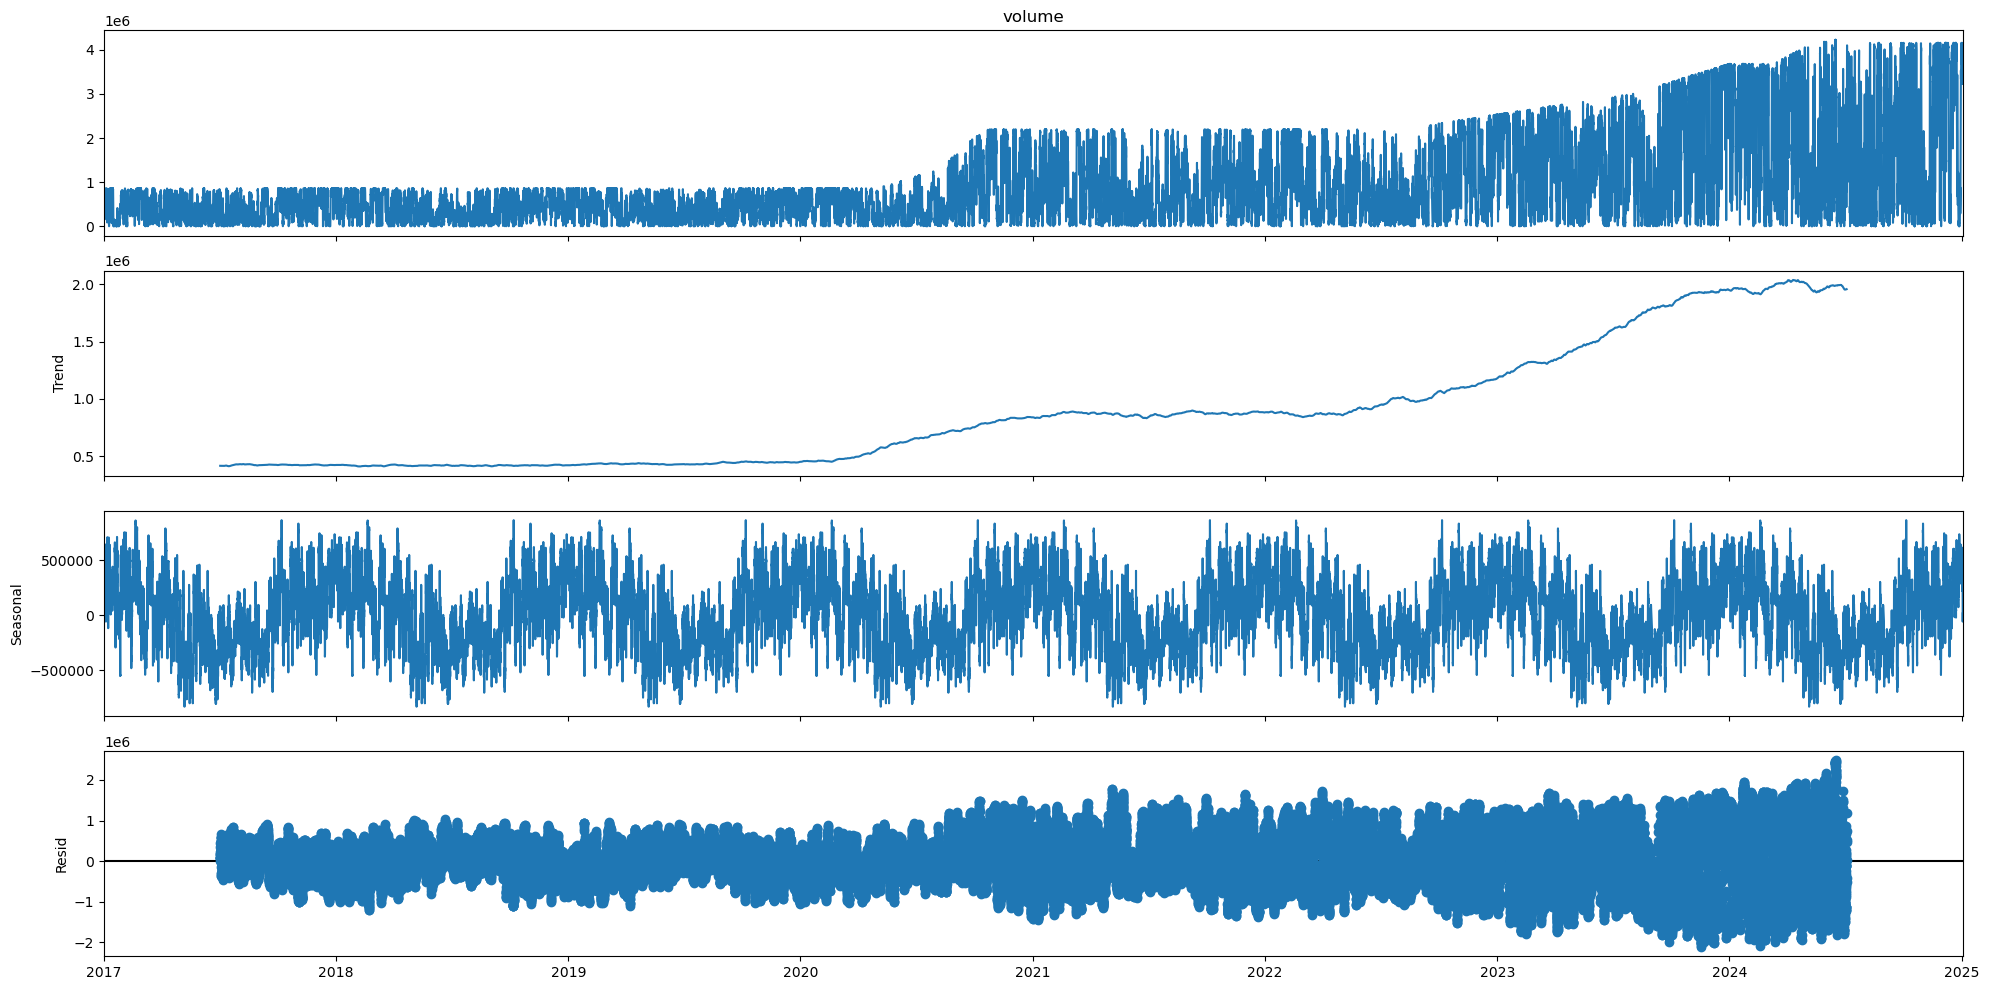

In [236]:
# Check for trend and seasonality for onshore data

decomposition_onshore = seasonal_decompose(db_onshore['volume'], 
                                 model='additive', 
                                 period=8760)  # Annual seasonality
fig = decomposition_onshore.plot()
fig.set_size_inches(20, 10)
plt.tight_layout()
plt.show()

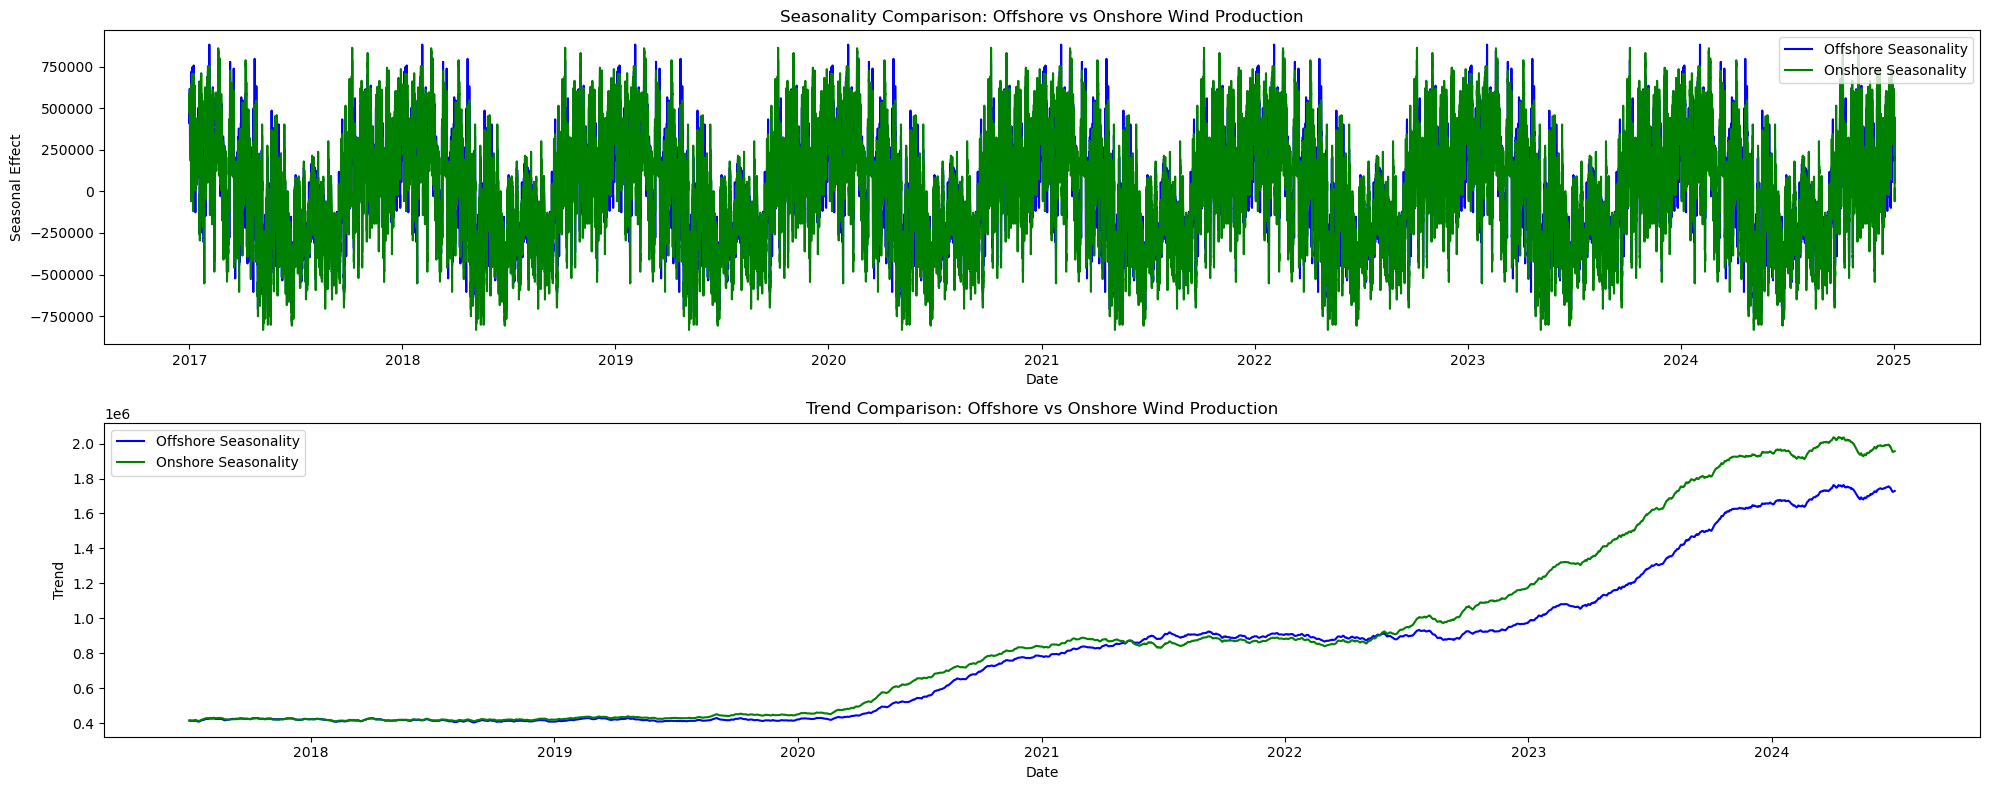

In [237]:
# Compare trend and seasonality for offshore and onshore data

decomp_offshore = seasonal_decompose(db_offshore['volume'], period=8760)
decomp_onshore = seasonal_decompose(db_onshore['volume'], period=8760)

plt.figure(figsize=(20, 8))

# Seasonal
plt.subplot(2, 1, 1)
plt.plot(decomp_offshore.seasonal, label='Offshore Seasonality', color='blue')
plt.plot(decomp_onshore.seasonal, label='Onshore Seasonality', color='green')
plt.title('Seasonality Comparison: Offshore vs Onshore Wind Production')
plt.xlabel('Date')
plt.ylabel('Seasonal Effect')
plt.legend()

# Trend
plt.subplot(2, 1, 2)
plt.plot(decomp_offshore.trend, label='Offshore Seasonality', color='blue')
plt.plot(decomp_onshore.trend, label='Onshore Seasonality', color='green')
plt.title('Trend Comparison: Offshore vs Onshore Wind Production')
plt.xlabel('Date')
plt.ylabel('Trend')
plt.legend()
plt.tight_layout()
plt.show()

**Conclusion: Both offshore and onshore datasets share similar trends and seasonality.**

•	Strong trend starting in 2020.

•	Clear seasonality across the entire period.

•	Some heteroskedasticity (changing variance) in residuals post-2022.

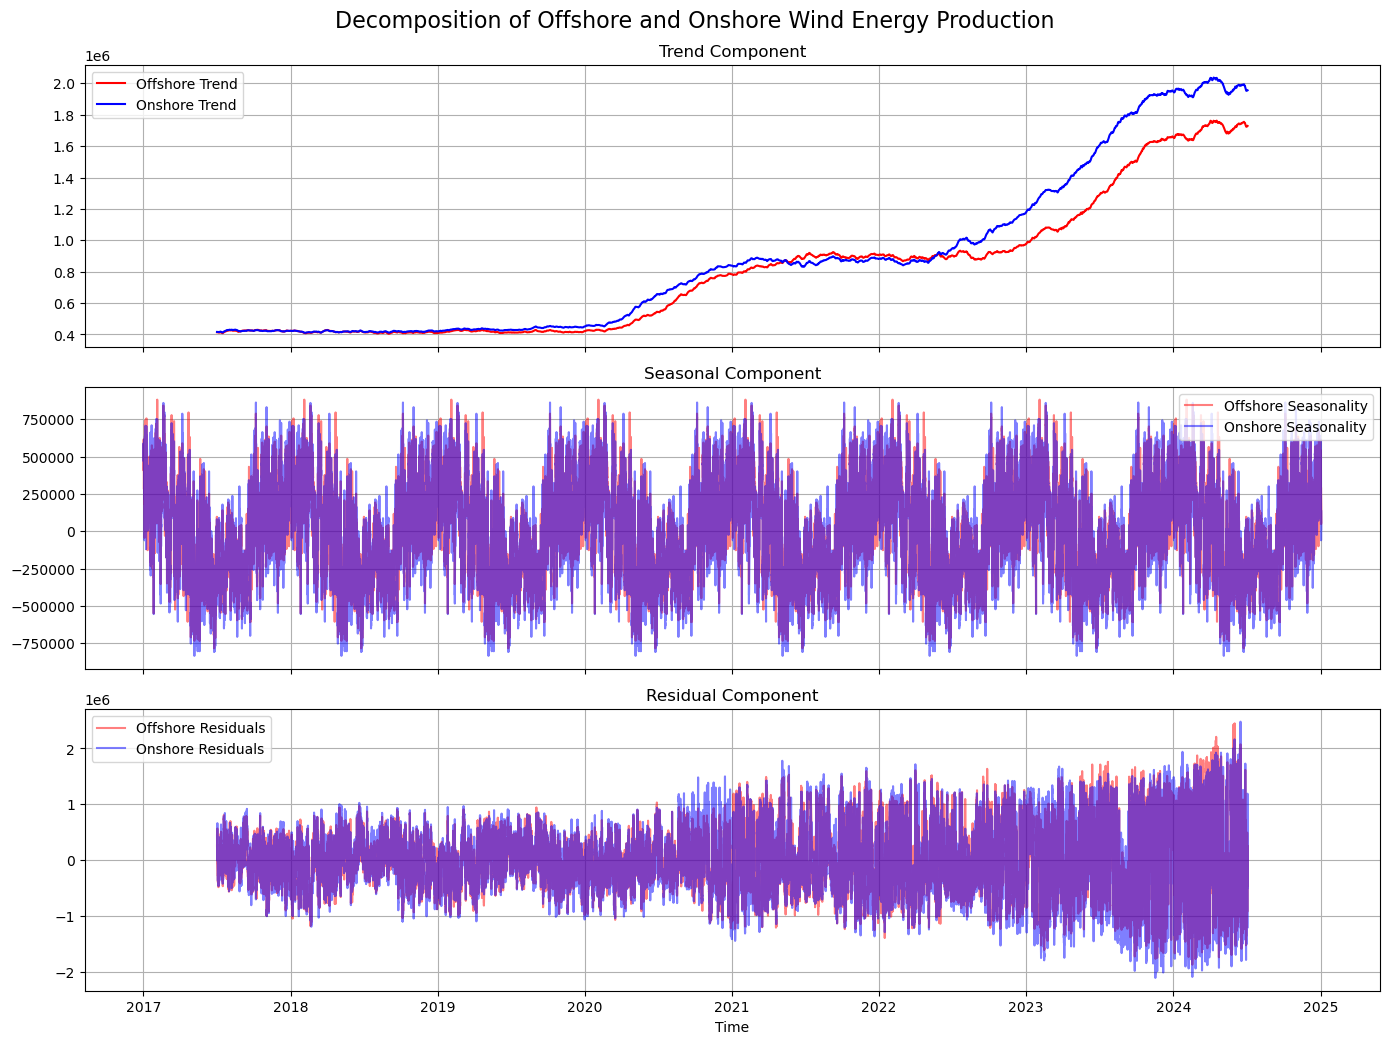

In [238]:
# Perform decomposition
decomp_offshore = seasonal_decompose(db_offshore['volume'], model='additive', period=8760)
decomp_onshore = seasonal_decompose(db_onshore['volume'], model='additive', period=8760)

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot Trend
axs[0].plot(decomp_offshore.trend, label='Offshore Trend', color='red')
axs[0].plot(decomp_onshore.trend, label='Onshore Trend', color='blue')
axs[0].set_title('Trend Component')
axs[0].legend()
axs[0].grid(True)

# Plot Seasonality
axs[1].plot(decomp_offshore.seasonal, label='Offshore Seasonality', color='red', alpha=0.5)
axs[1].plot(decomp_onshore.seasonal, label='Onshore Seasonality', color='blue', alpha=0.5)
axs[1].set_title('Seasonal Component')
axs[1].legend()
axs[1].grid(True)

# Plot Residuals
axs[2].plot(decomp_offshore.resid, label='Offshore Residuals', color='red', alpha=0.5)
axs[2].plot(decomp_onshore.resid, label='Onshore Residuals', color='blue', alpha=0.5)
axs[2].set_title('Residual Component')
axs[2].legend()
axs[2].grid(True)

# Formatting
plt.tight_layout()
plt.xlabel('Time')
plt.suptitle('Decomposition of Offshore and Onshore Wind Energy Production', fontsize=16, y=1.02)
plt.show()

##### Periodograms

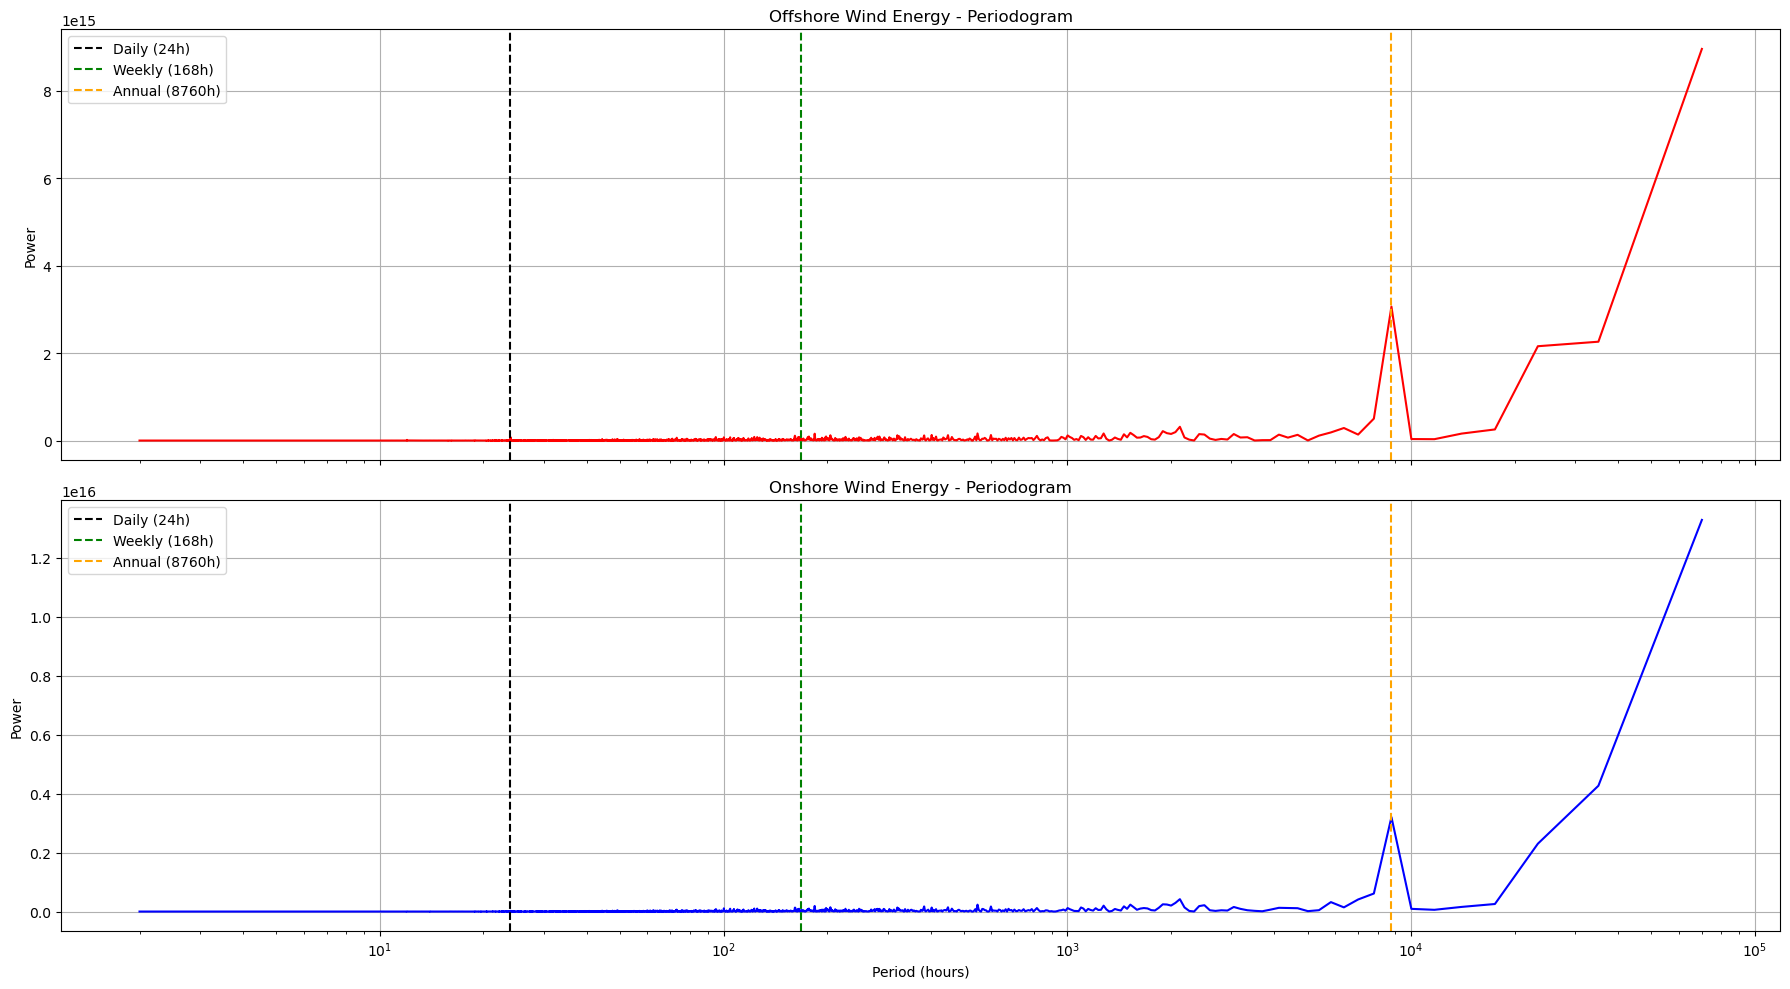

In [239]:
# Compute periodograms
f_offshore, Pxx_offshore = signal.periodogram(db_offshore['volume'].values, fs=1)  # hourly
f_onshore, Pxx_onshore = signal.periodogram(db_onshore['volume'].values, fs=1)

# Convert frequency to periods (skip f=0)
periods_offshore = 1 / f_offshore[1:]
power_offshore = Pxx_offshore[1:]

periods_onshore = 1 / f_onshore[1:]
power_onshore = Pxx_onshore[1:]

# Plot
fig, axs = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Offshore
axs[0].plot(periods_offshore, power_offshore, color='red')
axs[0].set_title('Offshore Wind Energy - Periodogram')
axs[0].set_ylabel('Power')
axs[0].set_xscale('log')
axs[0].axvline(x=24, color='black', linestyle='--', label='Daily (24h)')
axs[0].axvline(x=168, color='green', linestyle='--', label='Weekly (168h)')
axs[0].axvline(x=8760, color='orange', linestyle='--', label='Annual (8760h)')
axs[0].grid(True)
axs[0].legend()

# Onshore
axs[1].plot(periods_onshore, power_onshore, color='blue')
axs[1].set_title('Onshore Wind Energy - Periodogram')
axs[1].set_xlabel('Period (hours)')
axs[1].set_ylabel('Power')
axs[1].set_xscale('log')
axs[1].axvline(x=24, color='black', linestyle='--', label='Daily (24h)')
axs[1].axvline(x=168, color='green', linestyle='--', label='Weekly (168h)')
axs[1].axvline(x=8760, color='orange', linestyle='--', label='Annual (8760h)')
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()

**Conclusions: the periodograms reveals strong annual seasonality.**

•	Strong annual seasonality: The most prominent peak aligns perfectly with the annual (8760h) reference line in blue. This indicates a very strong yearly cycle in wind energy production.

•	Limited daily and weekly patterns: There's little to no significant power at the 24-hour (red) and 168-hour (green) markers. This suggests that daily and weekly cycles have minimal impact on wind energy production.

•	Noise characteristics: The relatively flat profile at shorter periods (left side of graph) suggests that short-term fluctuations in wind production are more random/white noise rather than following predictable patterns.

##### ACF (for seasonality)

The Autocorrelation Function (ACF) plot shows how strongly the time series is correlated with its own lagged values — how today’s value relates to past values (1 hour ago, 2 hours ago, …, 50 lags ago).

In [240]:
# Write ACF function
def plot_acf_series(series, lags=50, title=''):
    plt.figure(figsize=(10, 4))
    plot_acf(series.dropna(), lags=lags)
    plt.title(f"ACF Plot for {title}")
    plt.tight_layout()
    plt.show()

<Figure size 1000x400 with 0 Axes>

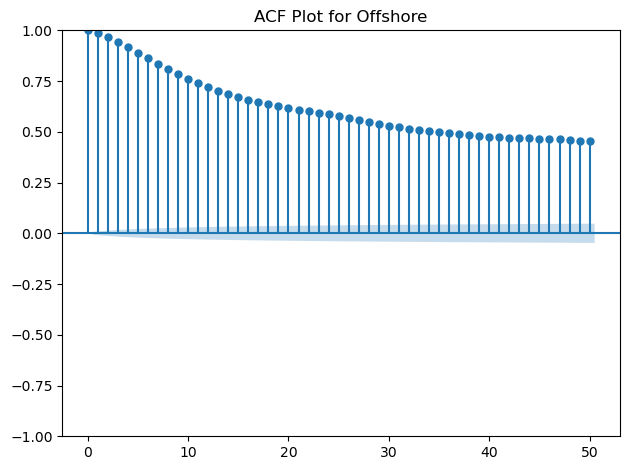

<Figure size 1000x400 with 0 Axes>

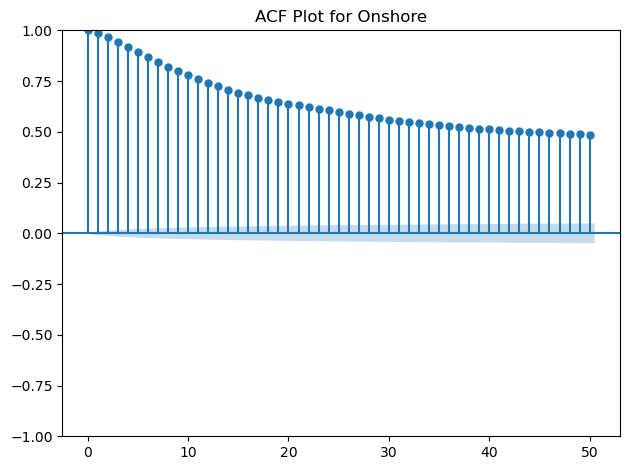

In [241]:
# ACF Plot
plot_acf_series(db_offshore['volume'], title='Offshore')
plot_acf_series(db_onshore['volume'], title='Onshore')

**Conclusions: We have a non-stationary dataset**

•	High autocorrelation at lag 1 (almost 1.0):
    This means today’s value is very strongly related to the previous hour’s value.

•	Slow, gradual decline in autocorrelations across lags:
    This is a typical sign of non-stationarity. The series has a persistent trend or pattern.

•	No sharp cutoff or sudden drop in autocorrelation:
    Suggests the process has long memory — past values continue to influence future ones.

##### Check for constant variance (homoscedasticity)

In [242]:
# Example: assuming your datasets have 'volume' as Y and 'hour', 'month' as predictors

# Offshore
model_offshore = smf.ols('volume ~ hour + month', data=db_offshore).fit()
bp_test_offshore = het_breuschpagan(model_offshore.resid, model_offshore.model.exog)

print("Breusch-Pagan Test (Offshore)")
print(f"LM stat: {bp_test_offshore[0]}, p-value: {bp_test_offshore[1]}")

# Onshore
model_onshore = smf.ols('volume ~ hour + month', data=db_onshore).fit()
bp_test_onshore = het_breuschpagan(model_onshore.resid, model_onshore.model.exog)

print("\nBreusch-Pagan Test (Onshore)")
print(f"LM stat: {bp_test_onshore[0]}, p-value: {bp_test_onshore[1]}")

Breusch-Pagan Test (Offshore)
LM stat: 24302.375672901515, p-value: 0.0

Breusch-Pagan Test (Onshore)
LM stat: 27662.017778408623, p-value: 0.0


**Conclusions: If p < 0.05 → reject null → heteroscedasticity detected**

##### Final remarks: ADF and KPSS tests for overall stationarity

In [243]:


def run_adf_test(series, name=''):
    print(f"\n🔍 ADF Test for {name}:")
    result = adfuller(series.dropna())
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    for key, value in result[4].items():
        print(f"Critical Value {key} : {value:.4f}")
    if result[1] < 0.05:
        print("✅ The series is likely stationary.")
    else:
        print("❌ The series is likely non-stationary.")

def run_kpss_test(series, name=''):
    print(f"\n🔍 KPSS Test for {name}:")
    result = kpss(series.dropna(), regression='c', nlags="auto")
    print(f"KPSS Statistic : {result[0]:.4f}")
    print(f"p-value        : {result[1]:.4f}")
    for key, value in result[3].items():
        print(f"Critical Value {key} : {value:.4f}")
    if result[1] < 0.05:
        print("❌ The series is likely non-stationary.")
    else:
        print("✅ The series is likely stationary.")

In [244]:
run_adf_test(db_onshore['volume'], name='Onshore Volume')
run_kpss_test(db_onshore['volume'], name='Onshore Volume')

run_adf_test(db_offshore['volume'], name='Offshore Volume')
run_kpss_test(db_offshore['volume'], name='Offshore Volume')


🔍 ADF Test for Onshore Volume:
ADF Statistic : -14.8717
p-value       : 0.0000
Critical Value 1% : -3.4304
Critical Value 5% : -2.8616
Critical Value 10% : -2.5668
✅ The series is likely stationary.

🔍 KPSS Test for Onshore Volume:
KPSS Statistic : 25.1584
p-value        : 0.0100
Critical Value 10% : 0.3470
Critical Value 5% : 0.4630
Critical Value 2.5% : 0.5740
Critical Value 1% : 0.7390
❌ The series is likely non-stationary.

🔍 ADF Test for Offshore Volume:


/var/folders/6x/v5640c0d6tjd96p_48y5_sy40000gn/T/ipykernel_5199/3819418763.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags="auto")


ADF Statistic : -15.5161
p-value       : 0.0000
Critical Value 1% : -3.4304
Critical Value 5% : -2.8616
Critical Value 10% : -2.5668
✅ The series is likely stationary.

🔍 KPSS Test for Offshore Volume:
KPSS Statistic : 23.0795
p-value        : 0.0100
Critical Value 10% : 0.3470
Critical Value 5% : 0.4630
Critical Value 2.5% : 0.5740
Critical Value 1% : 0.7390
❌ The series is likely non-stationary.


/var/folders/6x/v5640c0d6tjd96p_48y5_sy40000gn/T/ipykernel_5199/3819418763.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags="auto")


##### Overall conclusion

**We have a non-stationary time series data**

*Features of stationary time series data*:

1. **Constant Mean (no trend)**: The mean of the series remains constant over time.

    We have upward trend in both datasets, which is a sign of non-stationarity.

2. **Constant Variance**: The variance of the series remains constant over time.

    We detected heteroscedasticity in variance for both datasets.

3. **Constant autocorrelation structure over time (no seasonality)**: The series does not exhibit any seasonal patterns.
        
    We have strong annual seasonality in both datasets, which is a sign of non-stationarity.
    
    Also, ACF plot shows strong signs of non-stationarity.


### Splitting the data to train and test sets

#### Train and test sets

##### Offshore data

In [245]:
# Convert hourly data to monthly data
db_off_monthly = db_offshore.groupby('month').mean(numeric_only=True)

In [246]:
train_db_m_off = db_off_monthly[db_off_monthly.index <= '2024-06']
test_db_m_off = db_off_monthly[db_off_monthly.index > '2024-06']

In [247]:
# Convert hourly data to weekly data
db_off_weekly = db_offshore.groupby('week_number').mean(numeric_only=True)

In [248]:
train_db_w_off = db_off_weekly[db_off_weekly.index <= 406]
test_db_w_off = db_off_weekly[db_off_weekly.index > 406]

In [249]:
# Convert hourly data to daily data
db_offshore['date'] = pd.to_datetime(db_offshore['date'], format='ISO8601')
db_off_daily = db_offshore.groupby('date').mean(numeric_only=True)
db_off_daily.index = pd.to_datetime(db_off_daily.index)

In [250]:
train_db_d_off = db_off_daily[db_off_daily.index <= '2024-11-01']
test_db_d_off = db_off_daily[db_off_daily.index > '2024-11-01']

In [251]:
# Set hourly data
db_off_hourly = db_offshore

In [252]:
# Split into train and test set
train_db_h_off = db_off_hourly[db_off_hourly['date'] <= '2024-12-22']
test_db_h_off = db_off_hourly[db_off_hourly['date'] > '2024-12-22']

##### Onshore data

In [253]:
# Convert hourly data to monthly data
db_on_monthly = db_onshore.groupby('month').mean(numeric_only=True)

In [254]:
train_db_m_on = db_on_monthly[db_on_monthly.index <= '2024-06']
test_db_m_on = db_on_monthly[db_on_monthly.index > '2024-06']

In [255]:
# Convert hourly data to weekly data
db_on_weekly = db_onshore.groupby('week_number').mean(numeric_only=True)

In [256]:
train_db_w_on = db_on_weekly[db_on_weekly.index <= 406]
test_db_w_on = db_on_weekly[db_on_weekly.index > 406]

In [257]:
# Convert hourly data to daily data
db_onshore['date'] = pd.to_datetime(db_onshore['date'], format='ISO8601')
db_on_daily = db_onshore.groupby('date').mean(numeric_only=True)
db_on_daily.index = pd.to_datetime(db_on_daily.index)

In [258]:
train_db_d_on = db_on_daily[db_on_daily.index <= '2024-11-01']
test_db_d_on = db_on_daily[db_on_daily.index > '2024-11-01']

In [259]:
# Set hourly data
db_on_hourly = db_onshore

In [260]:
# Split into train and test set
train_db_h_on = db_on_hourly[db_on_hourly['date'] <= '2024-12-22']
test_db_h_on = db_on_hourly[db_on_hourly['date'] > '2024-12-22']

##### Plot for report

/var/folders/6x/v5640c0d6tjd96p_48y5_sy40000gn/T/ipykernel_5199/4061027729.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  train_monthly_rs = train_monthly['volume'].resample('M').mean()
/var/folders/6x/v5640c0d6tjd96p_48y5_sy40000gn/T/ipykernel_5199/4061027729.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  test_monthly_rs = test_monthly['volume'].resample('M').mean()


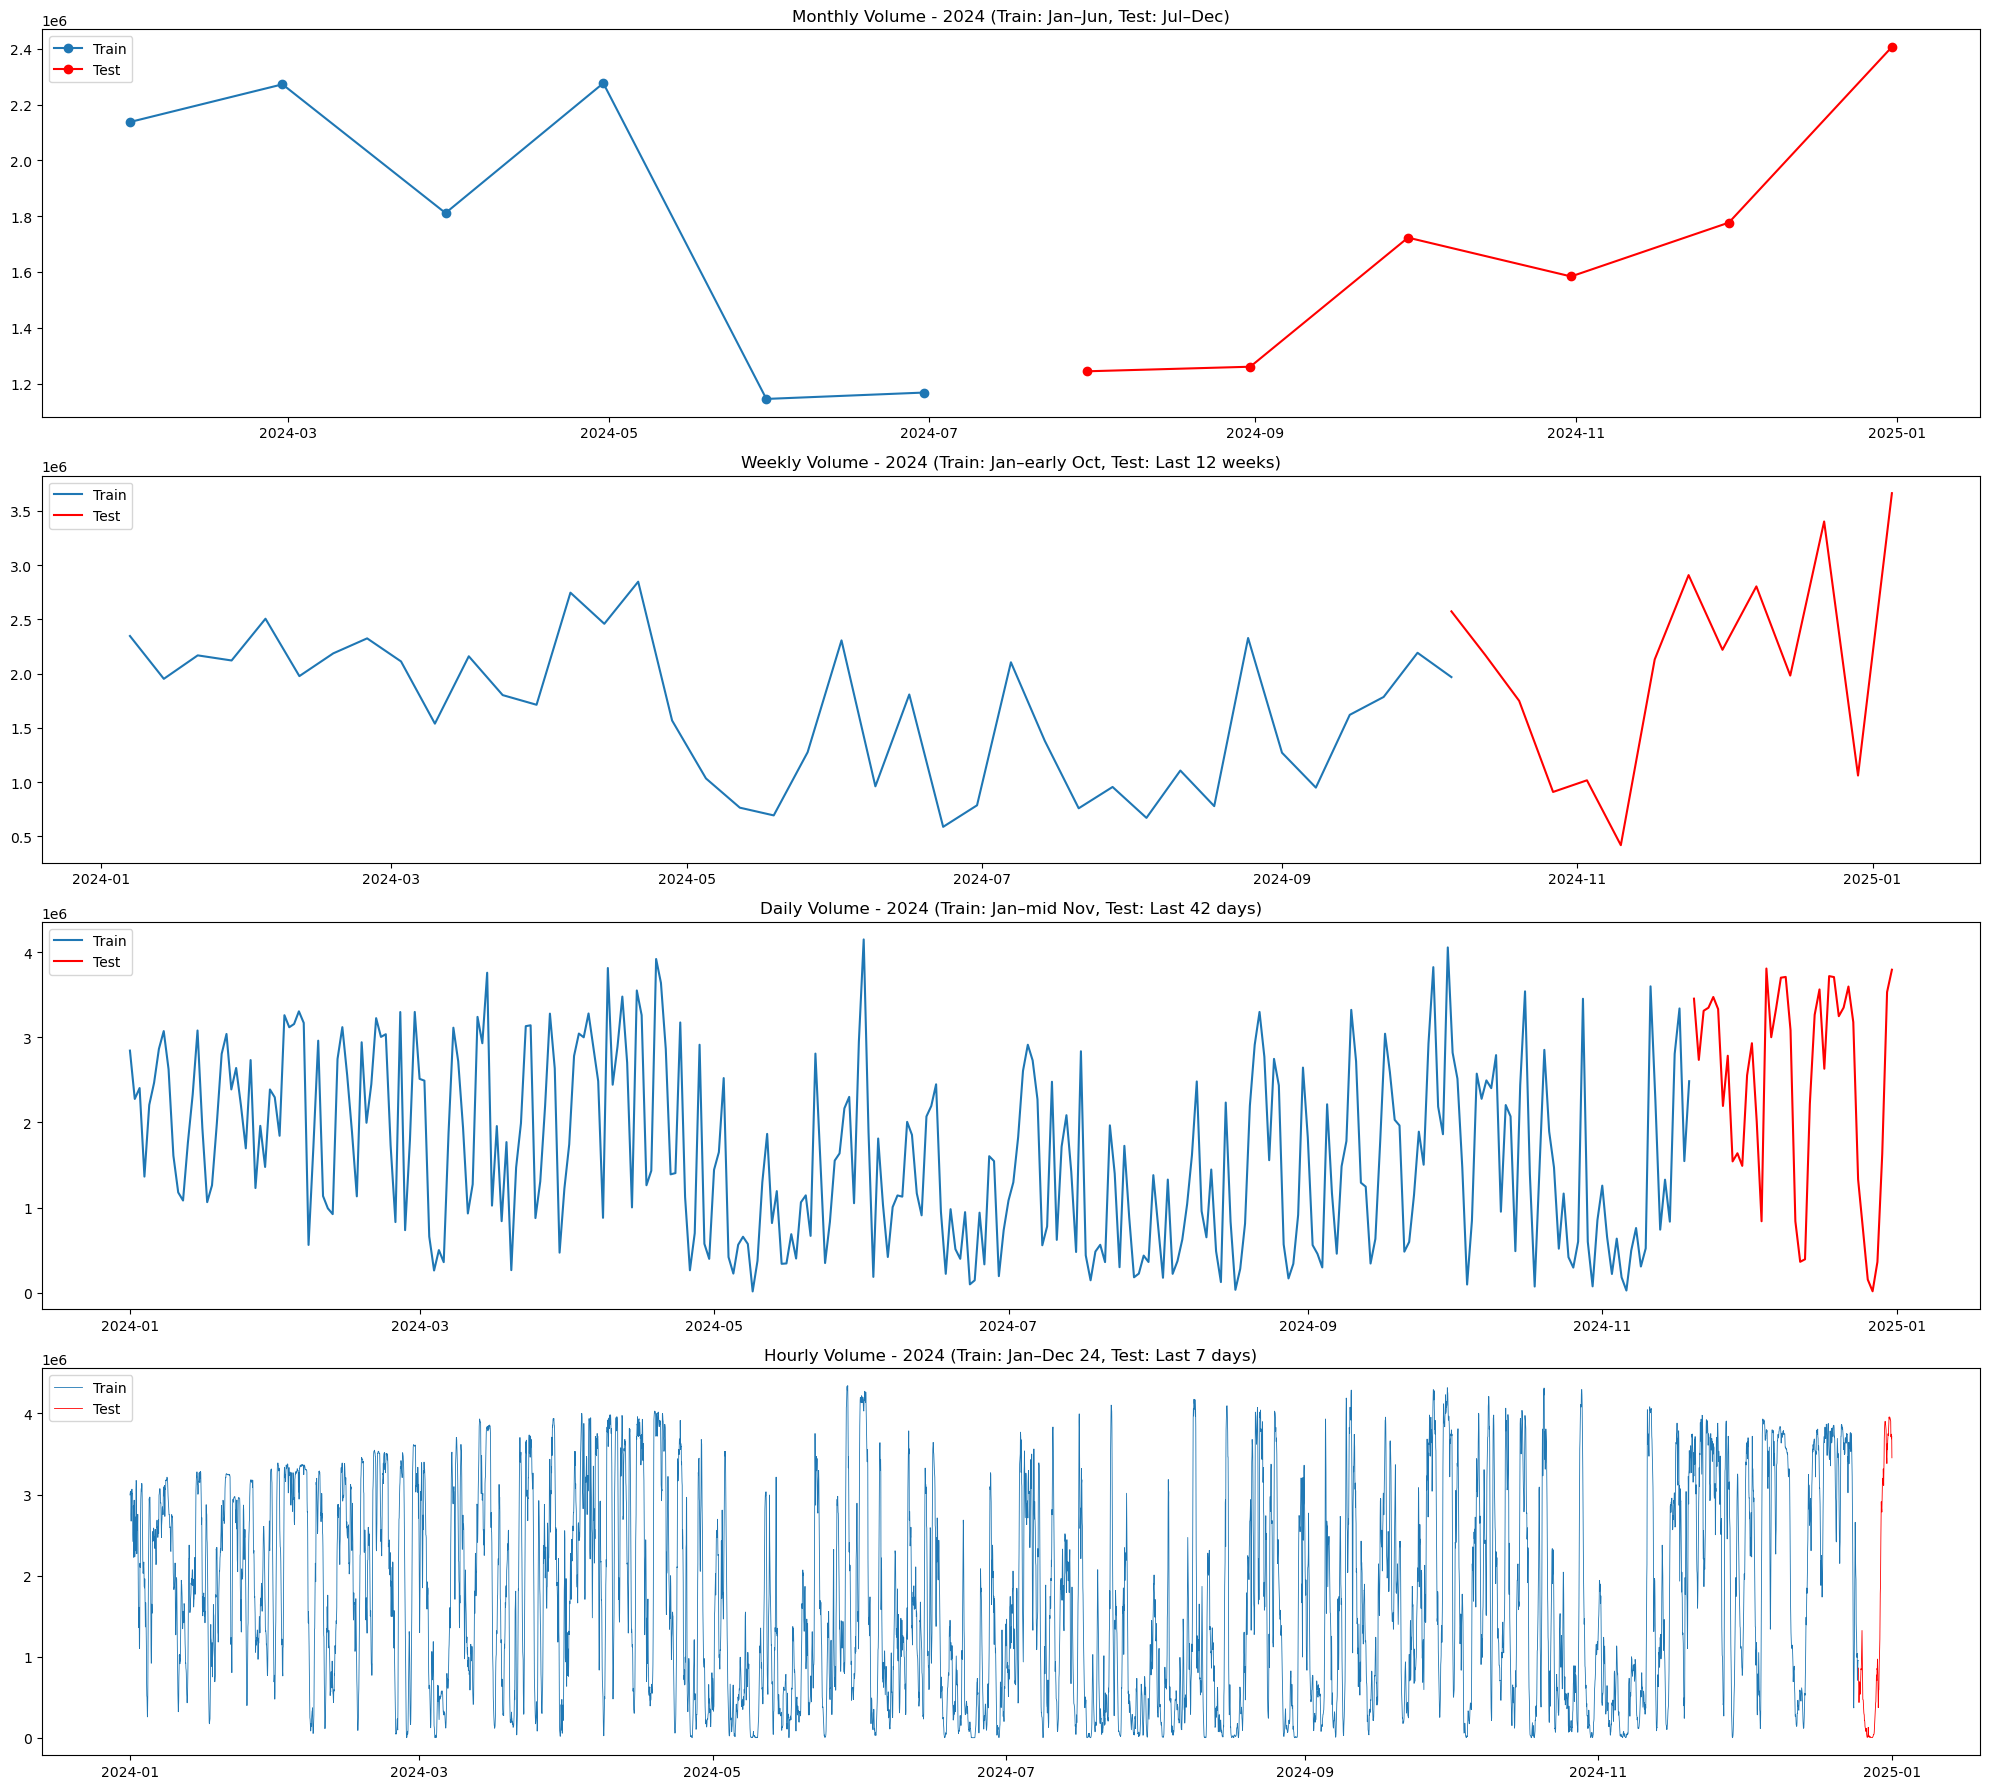

In [261]:
# Define full training base (only 2024)
start_2024 = '2024-01-01'
end_2024 = '2024-12-31'
data_2024 = db_offshore.loc[start_2024:end_2024]

# Define test sets
test_monthly = data_2024.loc['2024-07-01':'2024-12-31']
test_weekly = data_2024.loc['2024-10-06':'2024-12-31']
test_daily = data_2024.loc['2024-11-20':'2024-12-31']
test_hourly = data_2024.loc['2024-12-25':'2024-12-31']

# Corresponding train sets
train_monthly = data_2024.loc[start_2024:'2024-06-30']
train_weekly = data_2024.loc[start_2024:'2024-10-05']
train_daily = data_2024.loc[start_2024:'2024-11-19']
train_hourly = data_2024.loc[start_2024:'2024-12-24']

# Resample train and test
train_monthly_rs = train_monthly['volume'].resample('M').mean()
test_monthly_rs = test_monthly['volume'].resample('M').mean()

train_weekly_rs = train_weekly['volume'].resample('W').mean()
test_weekly_rs = test_weekly['volume'].resample('W').mean()

train_daily_rs = train_daily['volume'].resample('D').mean()
test_daily_rs = test_daily['volume'].resample('D').mean()

# Plotting
fig, axs = plt.subplots(4, 1, figsize=(20, 18), sharex=False)

# Monthly Plot (train + test merged for continuity)
axs[0].plot(train_monthly_rs.index, train_monthly_rs.values, label='Train', marker='o')
axs[0].plot(test_monthly_rs.index, test_monthly_rs.values, label='Test', marker='o', color='red')
axs[0].set_title('Monthly Volume - 2024 (Train: Jan–Jun, Test: Jul–Dec)')
axs[0].legend()

# Weekly
axs[1].plot(train_weekly_rs.index, train_weekly_rs.values, label='Train')
axs[1].plot(test_weekly_rs.index, test_weekly_rs.values, label='Test', color='red')
axs[1].set_title('Weekly Volume - 2024 (Train: Jan–early Oct, Test: Last 12 weeks)')
axs[1].legend()

# Daily
axs[2].plot(train_daily_rs.index, train_daily_rs.values, label='Train')
axs[2].plot(test_daily_rs.index, test_daily_rs.values, label='Test', color='red')
axs[2].set_title('Daily Volume - 2024 (Train: Jan–mid Nov, Test: Last 42 days)')
axs[2].legend()

# Hourly
axs[3].plot(train_hourly.index, train_hourly['volume'], label='Train', linewidth=0.6)
axs[3].plot(test_hourly.index, test_hourly['volume'], label='Test', color='red', linewidth=0.6)
axs[3].set_title('Hourly Volume - 2024 (Train: Jan–Dec 24, Test: Last 7 days)')
axs[3].legend()

plt.tight_layout()
plt.show()

### HW models

In [262]:
# Write the function for Holt-Winters additive model
def fit_and_forecast_hw_additive(train_series, test_series, seasonal_periods):

    # Ensure datetime index
    train_series.index = pd.to_datetime(train_series.index)
    test_series.index = pd.to_datetime(test_series.index)

    # Fit model
    model_fit = ExponentialSmoothing(
        train_series,
        trend='add',
        seasonal='add',
        seasonal_periods=seasonal_periods
    ).fit()

    # Forecast
    forecast = model_fit.forecast(len(test_series))
    #forecast.index = pd.date_range(start=train_series.index[-1] + pd.Timedelta(1, unit='D'), periods=len(test_series), freq=test_series.index.inferred_freq or 'D')

    return model_fit, forecast

#### Offshore data

##### Monthly data

In [263]:
hw_m_model, hw_m_forecast = fit_and_forecast_hw_additive(train_db_m_off['volume'], test_db_m_off['volume'], seasonal_periods=12)

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


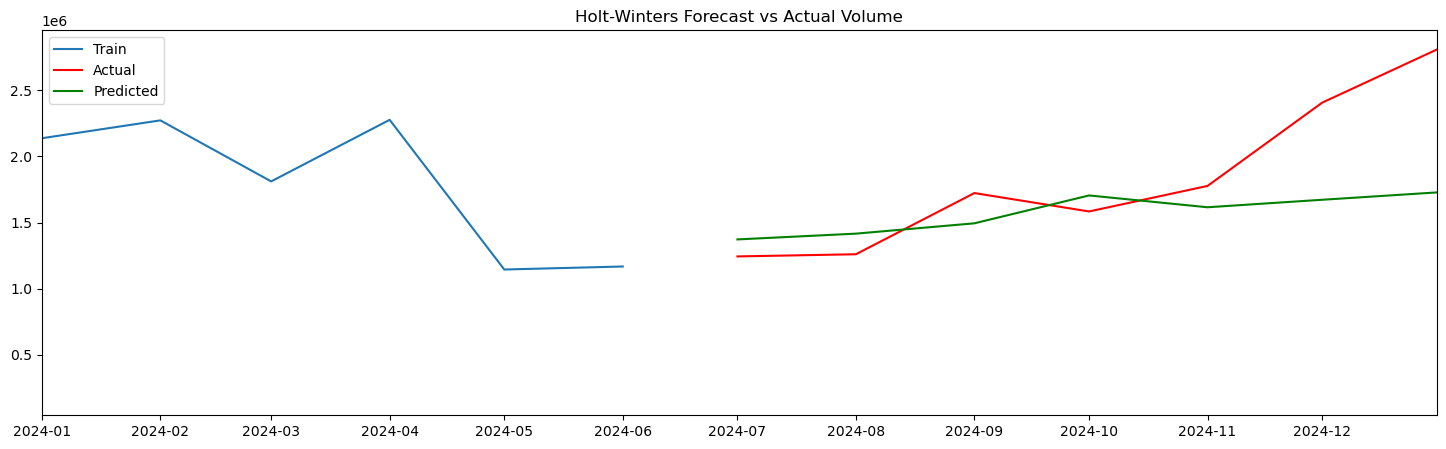

Mean Squared Error (MSE) for Holt-Winters Monthly: 266665297570.43
Root Mean Squared Error (RMSE) for Holt-Winters Monthly: 516396.45


In [264]:
plt.figure(figsize=(18, 5))
plt.plot(train_db_m_off['volume'], label="Train")
plt.plot(test_db_m_off['volume'], label="Actual", color='red')
plt.plot(hw_m_forecast, label="Predicted", color='green')
plt.legend()
plt.title("Holt-Winters Forecast vs Actual Volume")
plt.xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
plt.show()

# MSE
mse_hw_m = mean_squared_error(test_db_m_off['volume'], hw_m_forecast)
print(f"Mean Squared Error (MSE) for Holt-Winters Monthly: {mse_hw_m:.2f}")
# RMSE
rmse_hw_m = np.sqrt(mse_hw_m)
print(f"Root Mean Squared Error (RMSE) for Holt-Winters Monthly: {rmse_hw_m:.2f}")

##### Weekly data

In [265]:
hw_w_model, hw_w_forecast = fit_and_forecast_hw_additive(train_db_w_off['volume'], test_db_w_off['volume'], seasonal_periods=52)

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


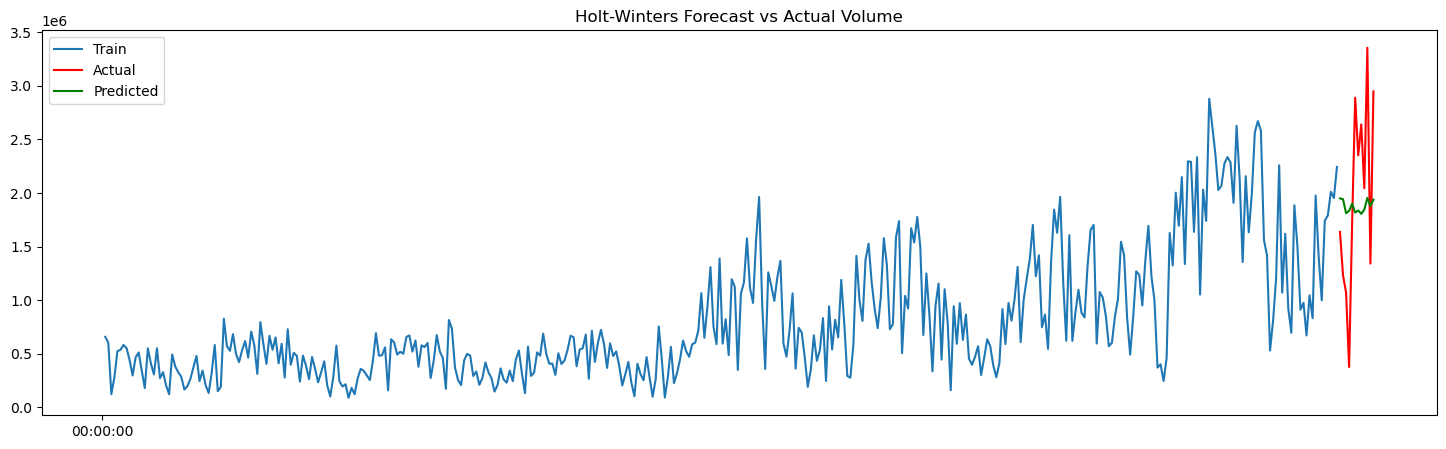

Mean Squared Error (MSE) for Holt-Winters Monthly: 727209771034.57
Root Mean Squared Error (RMSE) for Holt-Winters Monthly: 852765.95


In [266]:
plt.figure(figsize=(18,5))
plt.plot(train_db_w_off['volume'], label="Train")
plt.plot(test_db_w_off['volume'], label="Actual", color='red')
plt.plot(hw_w_forecast, label="Predicted", color='green')
plt.legend()
plt.title("Holt-Winters Forecast vs Actual Volume")
plt.show()

# MSE
mse_hw_w = mean_squared_error(test_db_w_off['volume'], hw_w_forecast)
print(f"Mean Squared Error (MSE) for Holt-Winters Monthly: {mse_hw_w:.2f}")
# RMSE
rmse_hw_w = np.sqrt(mse_hw_w)
print(f"Root Mean Squared Error (RMSE) for Holt-Winters Monthly: {rmse_hw_w:.2f}")

##### Daily data

In [267]:
hw_d_model, hw_d_forecast = fit_and_forecast_hw_additive(train_db_d_off['volume'], test_db_d_off['volume'], seasonal_periods=365)

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


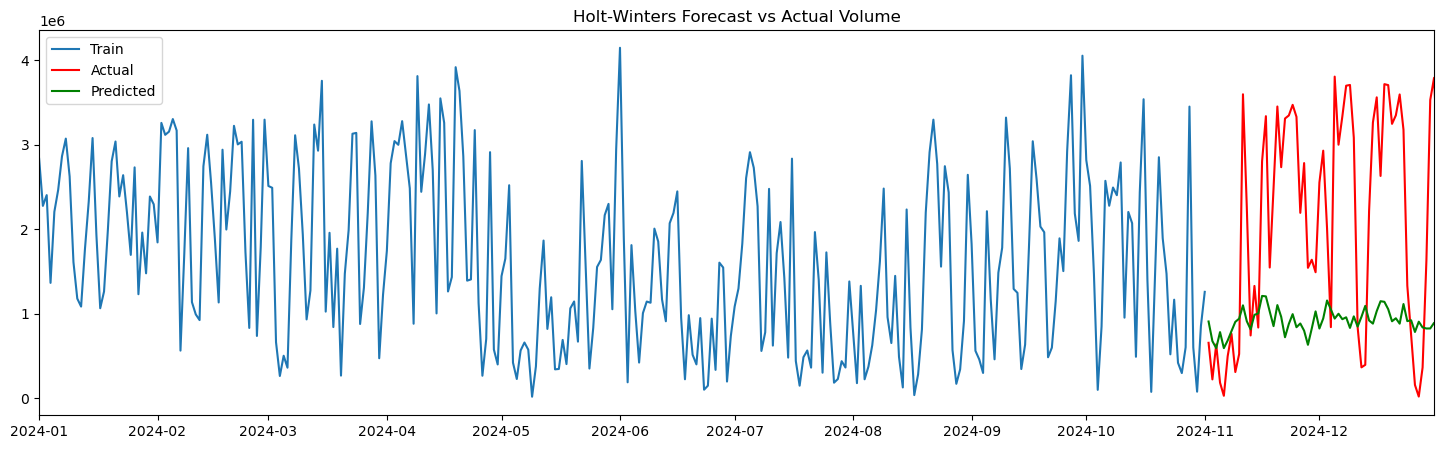

Mean Squared Error (MSE) for Holt-Winters Monthly: 2994256811130.51
Root Mean Squared Error (RMSE) for Holt-Winters Monthly: 1730392.10


In [268]:
plt.figure(figsize=(18, 5))
plt.plot(train_db_d_off['volume'], label="Train")
plt.plot(test_db_d_off['volume'], label="Actual", color='red')
plt.plot(hw_d_forecast, label="Predicted", color='green')
plt.legend()
plt.title("Holt-Winters Forecast vs Actual Volume")
plt.xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
plt.show()

# MSE
mse_hw_d = mean_squared_error(test_db_d_off['volume'], hw_d_forecast)
print(f"Mean Squared Error (MSE) for Holt-Winters Monthly: {mse_hw_d:.2f}")
# RMSE
rmse_hw_d = np.sqrt(mse_hw_d)
print(f"Root Mean Squared Error (RMSE) for Holt-Winters Monthly: {rmse_hw_d:.2f}")

##### Hourly data

In [269]:
# Alternative approach
# Assume `train_db_h` contains hourly wind energy production data
series = train_db_h_off['volume']

# Step 1: STL Decomposition
stl = STL(series, period=168)  # Weekly seasonality (24 hours * 7 days)
result = stl.fit()

# Extract components
trend = result.trend
seasonal = result.seasonal
residual = result.resid

# Step 2: Apply Holt-Winters to the trend component
hw_model = ExponentialSmoothing(trend.dropna(), trend='add', seasonal=None).fit()

# Step 3: Forecast trend and add seasonal component back
trend_forecast = hw_model.forecast(len(test_db_h_off))
seasonal_forecast = seasonal[-len(test_db_h_off):].values  # Repeat last known seasonality

final_forecast = trend_forecast + seasonal_forecast  # Reconstruct final forecast

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


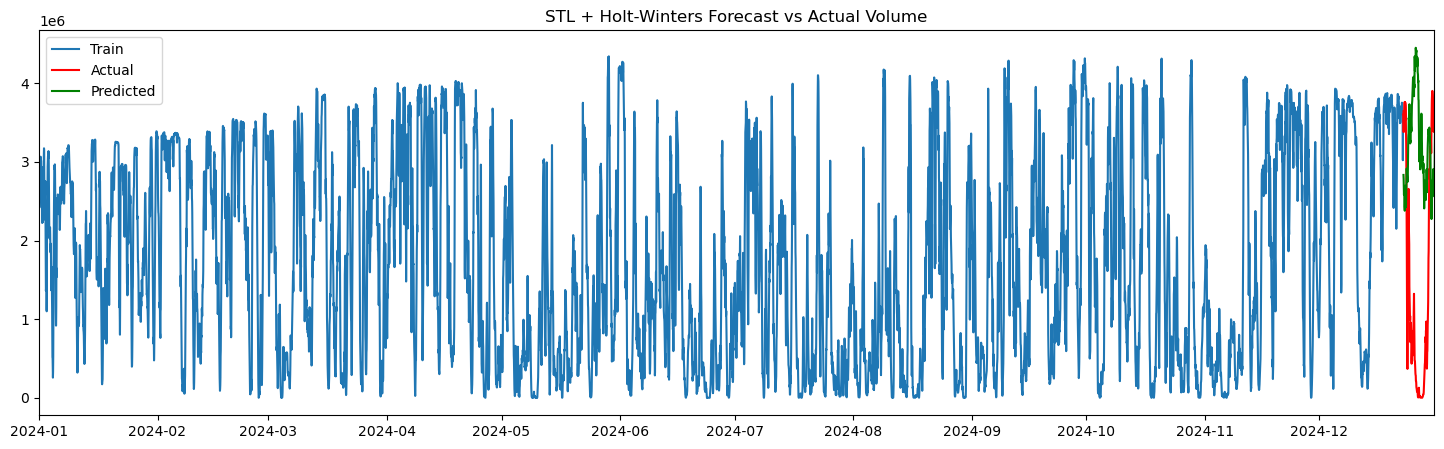

In [270]:
# Plot results
plt.figure(figsize=(18, 5))
plt.plot(train_db_h_off.index, train_db_h_off['volume'], label="Train")
plt.plot(test_db_h_off.index, test_db_h_off['volume'], label="Actual", color='red')
plt.plot(test_db_h_off.index, final_forecast, label="Predicted", color='green')
plt.legend()
plt.title("STL + Holt-Winters Forecast vs Actual Volume")
plt.xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
plt.show()

In [271]:
# MSE
mse_hw_h = mean_squared_error(test_db_h_off['volume'], final_forecast)
print(f"Mean Squared Error (MSE) for Holt-Winters Monthly: {mse_hw_h:.2f}")
# RMSE
rmse_hw_h = np.sqrt(mse_hw_h)
print(f"Root Mean Squared Error (RMSE) for Holt-Winters Monthly: {rmse_hw_h:.2f}")

Mean Squared Error (MSE) for Holt-Winters Monthly: 5430719079090.89
Root Mean Squared Error (RMSE) for Holt-Winters Monthly: 2330390.33


#### ALT TAKE (LOG_VOLUME): Offshore data

##### Daily data

In [272]:
train_db_d_off['log_volume'] = np.log(train_db_d_off['volume'])
test_db_d_off['log_volume'] = np.log(test_db_d_off['volume'])

/var/folders/6x/v5640c0d6tjd96p_48y5_sy40000gn/T/ipykernel_5199/1634191168.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_db_d_off['log_volume'] = np.log(train_db_d_off['volume'])
/var/folders/6x/v5640c0d6tjd96p_48y5_sy40000gn/T/ipykernel_5199/1634191168.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_db_d_off['log_volume'] = np.log(test_db_d_off['volume'])


In [273]:
hw_d_model_log, hw_d_forecast_log = fit_and_forecast_hw_additive(train_db_d_off['log_volume'], 
                                                                 test_db_d_off['log_volume'], 
                                                                 seasonal_periods=365)

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


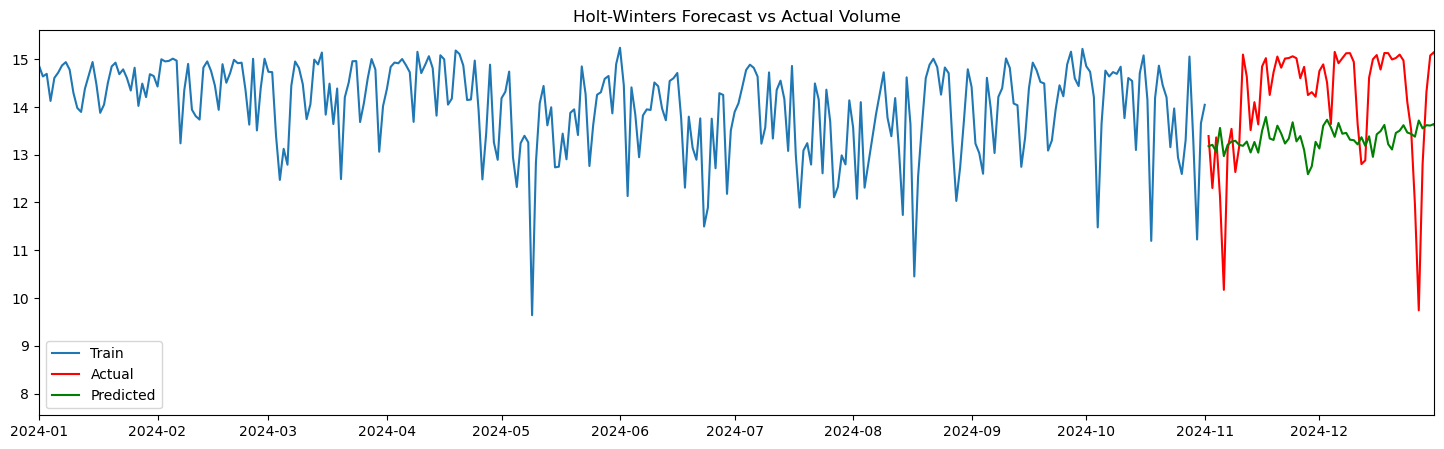

Mean Squared Error (MSE) for Holt-Winters Monthly: 2.02
Root Mean Squared Error (RMSE) for Holt-Winters Monthly: 1.42
RMSE (back-transformed): 1118227.72


In [275]:
plt.figure(figsize=(18,5))
plt.plot(train_db_d_off['log_volume'], label="Train")
plt.plot(test_db_d_off['log_volume'], label="Actual", color='red')
plt.plot(hw_d_forecast_log, label="Predicted", color='green')
plt.legend()
plt.title("Holt-Winters Forecast vs Actual Volume")
plt.xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
plt.show()

# MSE
mse_hw_d_log = mean_squared_error(test_db_d_off['log_volume'], hw_d_forecast_log)
print(f"Mean Squared Error (MSE) for Holt-Winters Monthly: {mse_hw_d_log:.2f}")
# RMSE
rmse_hw_d_log = np.sqrt(mse_hw_d_log)
print(f"Root Mean Squared Error (RMSE) for Holt-Winters Monthly: {rmse_hw_d_log:.2f}")

print(f"RMSE (back-transformed): {rmse:.2f}")

In [173]:
y_pred = np.exp(hw_d_forecast_log)
y_true_transformed = np.exp(test_db_d_off['log_volume'])  # Should match y_true

# 4. Compare in original scale
mse = mean_squared_error(y_true_transformed, y_pred)
rmse = np.sqrt(mse)

print(f"MSE (back-transformed): {mse:.2f}")
print(f"RMSE (back-transformed): {rmse:.2f}")

MSE (back-transformed): 3754662493837.53
RMSE (back-transformed): 1937695.15


#### Onshore data

##### Monthly data

In [276]:
hw_m_model, hw_m_forecast = fit_and_forecast_hw_additive(train_db_m_on['volume'], test_db_m_on['volume'], seasonal_periods=12)

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


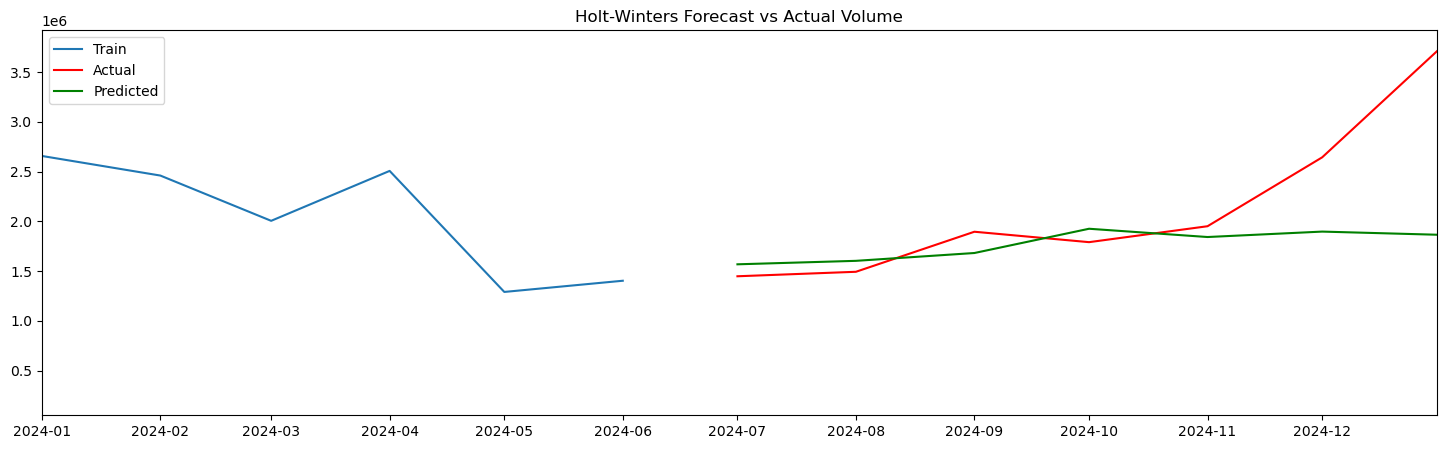

Mean Squared Error (MSE) for Holt-Winters Monthly: 599083158498.66
Root Mean Squared Error (RMSE) for Holt-Winters Monthly: 774004.62


In [277]:
plt.figure(figsize=(18, 5))
plt.plot(train_db_m_on['volume'], label="Train")
plt.plot(test_db_m_on['volume'], label="Actual", color='red')
plt.plot(hw_m_forecast, label="Predicted", color='green')
plt.legend()
plt.title("Holt-Winters Forecast vs Actual Volume")
plt.xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
plt.show()

# MSE
mse_hw_m = mean_squared_error(test_db_m_on['volume'], hw_m_forecast)
print(f"Mean Squared Error (MSE) for Holt-Winters Monthly: {mse_hw_m:.2f}")
# RMSE
rmse_hw_m = np.sqrt(mse_hw_m)
print(f"Root Mean Squared Error (RMSE) for Holt-Winters Monthly: {rmse_hw_m:.2f}")

##### Weekly data

In [278]:
hw_w_model, hw_w_forecast = fit_and_forecast_hw_additive(train_db_w_on['volume'], test_db_w_on['volume'], seasonal_periods=52)

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


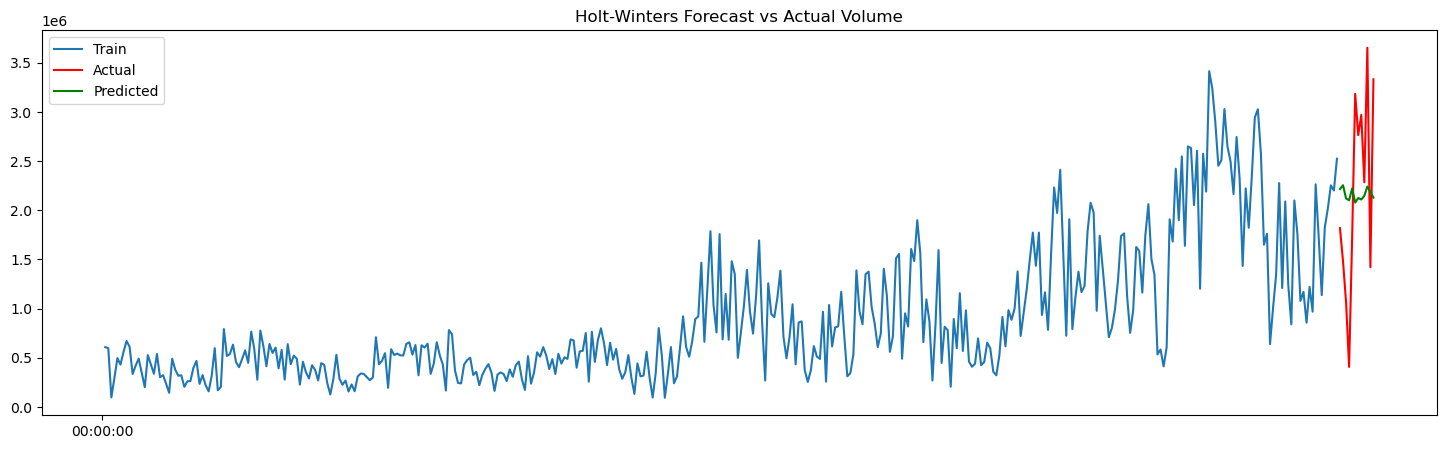

Mean Squared Error (MSE) for Holt-Winters Monthly: 950306810769.19
Root Mean Squared Error (RMSE) for Holt-Winters Monthly: 974836.81


In [279]:
plt.figure(figsize=(18,5))
plt.plot(train_db_w_on['volume'], label="Train")
plt.plot(test_db_w_on['volume'], label="Actual", color='red')
plt.plot(hw_w_forecast, label="Predicted", color='green')
plt.legend()
plt.title("Holt-Winters Forecast vs Actual Volume")
plt.show()

# MSE
mse_hw_w = mean_squared_error(test_db_w_on['volume'], hw_w_forecast)
print(f"Mean Squared Error (MSE) for Holt-Winters Monthly: {mse_hw_w:.2f}")
# RMSE
rmse_hw_w = np.sqrt(mse_hw_w)
print(f"Root Mean Squared Error (RMSE) for Holt-Winters Monthly: {rmse_hw_w:.2f}")

##### Daily data

In [280]:
hw_d_model, hw_d_forecast = fit_and_forecast_hw_additive(train_db_d_on['volume'], test_db_d_on['volume'], seasonal_periods=365)

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


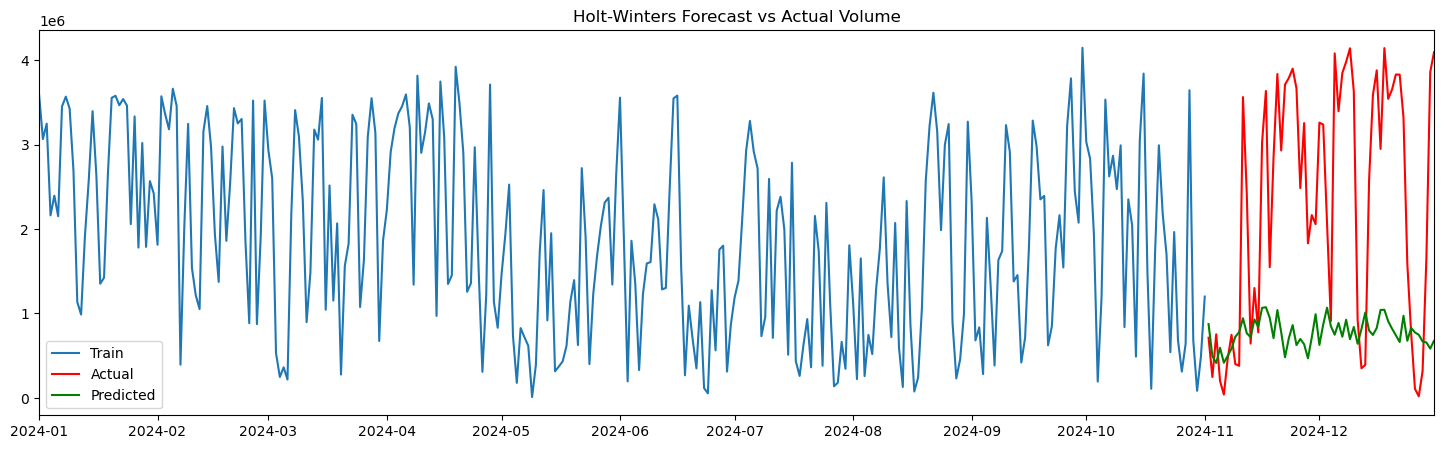

Mean Squared Error (MSE) for Holt-Winters Monthly: 4438111666335.28
Root Mean Squared Error (RMSE) for Holt-Winters Monthly: 2106682.62


In [281]:
plt.figure(figsize=(18, 5))
plt.plot(train_db_d_on['volume'], label="Train")
plt.plot(test_db_d_on['volume'], label="Actual", color='red')
plt.plot(hw_d_forecast, label="Predicted", color='green')
plt.legend()
plt.title("Holt-Winters Forecast vs Actual Volume")
plt.xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
plt.show()

# MSE
mse_hw_d = mean_squared_error(test_db_d_on['volume'], hw_d_forecast)
print(f"Mean Squared Error (MSE) for Holt-Winters Monthly: {mse_hw_d:.2f}")
# RMSE
rmse_hw_d = np.sqrt(mse_hw_d)
print(f"Root Mean Squared Error (RMSE) for Holt-Winters Monthly: {rmse_hw_d:.2f}")

##### Hourly data

In [282]:
# Alternative approach
# Assume `train_db_h` contains hourly wind energy production data
series = train_db_h_on['volume']

# Step 1: STL Decomposition
stl = STL(series, period=168)  # Weekly seasonality (24 hours * 7 days)
result = stl.fit()

# Extract components
trend = result.trend
seasonal = result.seasonal
residual = result.resid

# Step 2: Apply Holt-Winters to the trend component
hw_model = ExponentialSmoothing(trend.dropna(), trend='add', seasonal=None).fit()

# Step 3: Forecast trend and add seasonal component back
trend_forecast = hw_model.forecast(len(test_db_h_on))
seasonal_forecast = seasonal[-len(test_db_h_on):].values  # Repeat last known seasonality

final_forecast = trend_forecast + seasonal_forecast  # Reconstruct final forecast

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


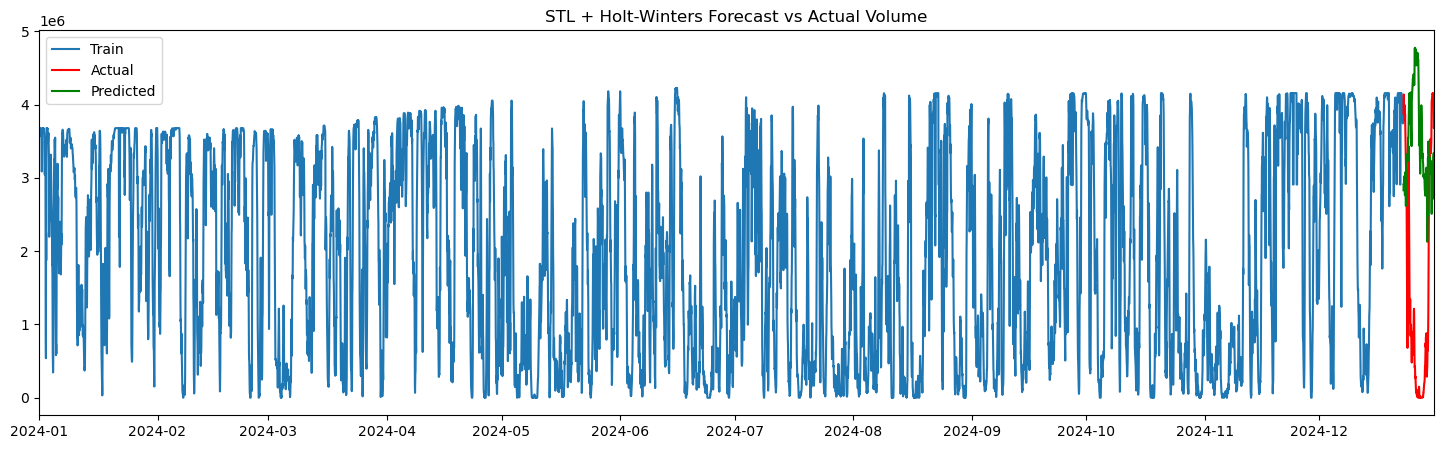

In [283]:
# Plot results
plt.figure(figsize=(18, 5))
plt.plot(train_db_h_on.index, train_db_h_on['volume'], label="Train")
plt.plot(test_db_h_on.index, test_db_h_on['volume'], label="Actual", color='red')
plt.plot(test_db_h_on.index, final_forecast, label="Predicted", color='green')
plt.legend()
plt.title("STL + Holt-Winters Forecast vs Actual Volume")
plt.xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
plt.show()

In [284]:
# MSE
mse_hw_h = mean_squared_error(test_db_h_on['volume'], final_forecast)
print(f"Mean Squared Error (MSE) for Holt-Winters Monthly: {mse_hw_h:.2f}")
# RMSE
rmse_hw_h = np.sqrt(mse_hw_h)
print(f"Root Mean Squared Error (RMSE) for Holt-Winters Monthly: {rmse_hw_h:.2f}")

Mean Squared Error (MSE) for Holt-Winters Monthly: 6386199826934.86
Root Mean Squared Error (RMSE) for Holt-Winters Monthly: 2527093.16


### SARIMAX models

#### Offshore data

In [285]:
def fit_predict_plot_sarimax(train_db, test_db, target_var, exclude_cols=None,
                             order=(3,1,0), seasonal_periods=12):
    if exclude_cols is None:
        exclude_cols = []

    # 1. Prepare exogenous variables
    drop_cols = [col for col in [target_var] + exclude_cols if col in train_db.columns]
    exog_vars = train_db.columns.drop(drop_cols)
    exog_feature_names = exog_vars.tolist()

    scaler = StandardScaler()
    train_exog_scaled = scaler.fit_transform(train_db[exog_vars])
    test_exog_scaled = scaler.transform(test_db[exog_vars])

    # 2. Define seasonal_order based on provided seasonal_periods
    seasonal_order = (1, 1, 1, seasonal_periods)

    # 3. Fit SARIMAX model
    model = SARIMAX(
        train_db[target_var],
        exog=train_exog_scaled,
        order=order,
        seasonal_order=seasonal_order
    )
    model_fit = model.fit(disp=True)

    # 4. Get t-statistics of exogenous coefficients
    exog_coeffs = model_fit.params[model_fit.model.exog_names]
    exog_t_stats = (exog_coeffs / model_fit.bse[model_fit.model.exog_names]).sort_values(ascending=False)

    # 5. Make predictions
    predictions = model_fit.predict(
        start=len(train_db[target_var]),
        end=len(train_db[target_var]) + len(test_db[target_var]) - 1,
        exog=test_exog_scaled,
        dynamic=False
    )

    # 6. Plot results
    plt.figure(figsize=(18,5))
    plt.plot(train_db[target_var], label="Train")
    plt.plot(test_db[target_var], label="Actual", color='red')
    plt.plot(predictions, label="Predicted", color='green')
    plt.legend()
    plt.title(f"SARIMAX Forecast vs Actual Volume (Seasonal Periods: {seasonal_periods})")
    plt.xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
    plt.show()

    # 7. Print MSE
    mse = mean_squared_error(test_db[target_var], predictions)
    rmse = np.sqrt(mse)
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

    return model_fit, predictions, exog_t_stats

##### Monthly data

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


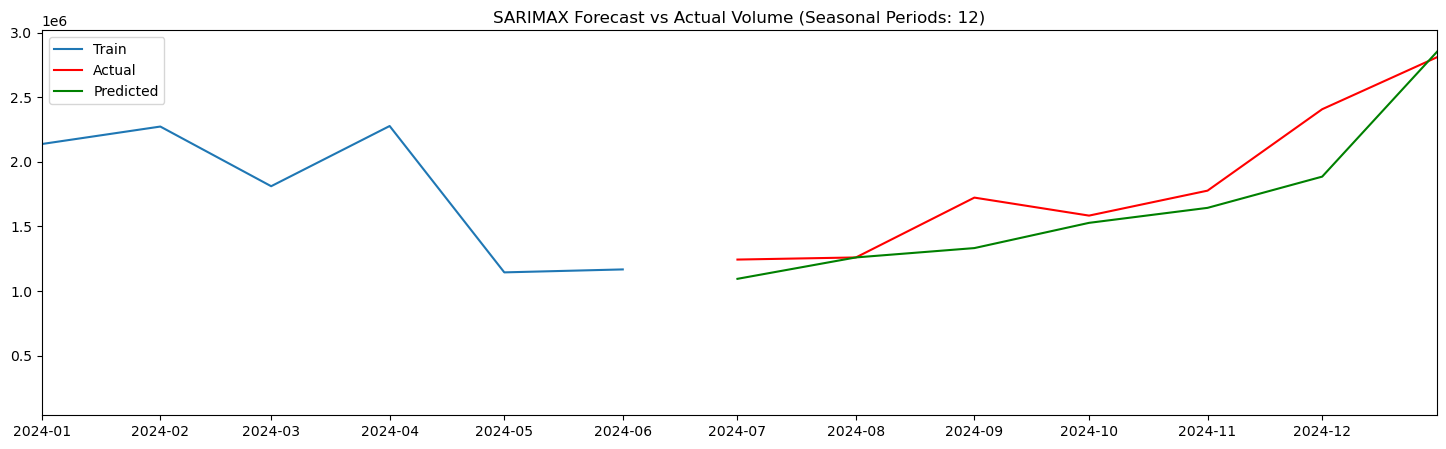

Mean Squared Error (MSE): 67301640771.54
Root Mean Squared Error (RMSE): 259425.60


In [286]:
model_fit_m_off, predictions_m_off, t_stats_m_off = fit_predict_plot_sarimax(
    train_db=train_db_m_off,
    test_db=test_db_m_off,
    target_var='volume',
    exclude_cols=['capacity', 'week_number', 'percentage', 'wind_speed_avg_10'],
    order=(3,1,1),
    seasonal_periods=12
)

##### Weekly data

In [287]:
# Retrieve exogenous variables
exog_vars = train_db_w_off.columns.drop(['volume', 'wind_speed_avg_10', 'percentage', 'capacity'])

# Standartise variables
scaler = StandardScaler()
train_exog_scaled_w = scaler.fit_transform(train_db_w_off[exog_vars])
test_exog_scaled_w = scaler.transform(test_db_w_off[exog_vars])

# Fit the model
model = SARIMAX(
        train_db_w_off['volume'], 
        exog=train_exog_scaled_w,
        order=(3,1,0),  # ARIMA components
        seasonal_order=(1,1,1,52)  # Seasonal components
    )
model_fit = model.fit(disp=True)

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)


In [288]:
exog_coeffs = model_fit.params[model_fit.model.exog_names]
exog_t_stats = exog_coeffs / model_fit.bse[model_fit.model.exog_names]
exog_t_stats.sort_values(ascending=False)

x2    14.772515
x3     1.071439
x1     0.551832
x4     0.021012
dtype: float64

In [289]:
# Predict
predictions = model_fit.predict(
    start=len(train_db_w_off['volume']), 
    end=len(train_db_w_off['volume']) + len(test_db_w_off['volume']) - 1, 
    exog=test_exog_scaled_w, 
    dynamic=False)

In [291]:
# Plot predictions
plt.figure(figsize=(18,5))
#plt.plot(train_db_w['volume'], label="Train")
#plt.plot(test_db_w['volume'], label="Actual", color='red')
#plt.plot(predictions, label="Predicted", color='green')
#plt.legend()
#plt.title("SARIMAX Forecast vs Actual Volume")
#plt.show()

# Filter 2024 data
#train_subset = train_db_w_off[train_db_w_off.index >= 300]
#test_subset = test_db_w_off[test_db_w_off.index >= 300]
##pred_subset = predictions[predictions.index >= 300]

#plt.plot(train_subset['volume'], label="Train")
#plt.plot(test_subset['volume'], label="Actual", color='red')
#plt.plot(pred_subset, label="Predicted", color='green')

#plt.legend()
#plt.title("SARIMAX Forecast vs Actual Volume (2024)")
#plt.show()

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

In [292]:
# Compute MSE and RMSE
mse = mean_squared_error(test_db_w_off['volume'], predictions)
print(f'Mean Squared Error (MSE): {mse:.2f}')
rmse = np.sqrt(mean_squared_error(test_db_w_off['volume'], predictions))
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Squared Error (MSE): 463854445654.43
Root Mean Squared Error (RMSE): 681068.61


##### Daily data

In [ ]:
# Retrieve exogenous variables
exog_vars = train_db_d_off.columns.drop(['volume', 'wind_speed_avg_10', 'percentage', 'capacity', 'week_number'])

# Standartise variables
scaler = StandardScaler()
train_exog_scaled_d = scaler.fit_transform(train_db_d_off[exog_vars])
test_exog_scaled_d = scaler.transform(test_db_d_off[exog_vars])

# Alternative approach: 
stl = STL(train_db_d_off['volume'], period=365)
result = stl.fit()
train_db_d_off['deseasonalized'] = train_db_d_off['volume'] - result.seasonal

# Now apply SARIMA to deseasonalized data
model = SARIMAX(
        train_db_d_off['deseasonalized'], 
        exog=train_exog_scaled_d,
        order=(3,1,0),
        seasonal_order=(1,1,1,30)
  )  # Use a smaller seasonal period like 30 (monthly) if needed

model_fit = model.fit(disp=True)

/var/folders/6x/v5640c0d6tjd96p_48y5_sy40000gn/T/ipykernel_5199/813568572.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_db_d_off['deseasonalized'] = train_db_d_off['volume'] - result.seasonal
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [214]:
exog_coeffs = model_fit.params[model_fit.model.exog_names]
exog_t_stats = exog_coeffs / model_fit.bse[model_fit.model.exog_names]
exog_t_stats.sort_values(ascending=False)

x2    9.839491
x5    9.690042
x4   -0.140652
x3   -0.163612
x1   -0.842259
dtype: float64

In [ ]:
# Predict 
predictions = model_fit.predict(
    start=len(train_db_d_off['volume']), 
    end=len(train_db_d_off['volume']) + len(test_db_d_off['volume']) - 1, 
    exog=test_exog_scaled_d, 
    dynamic=False)

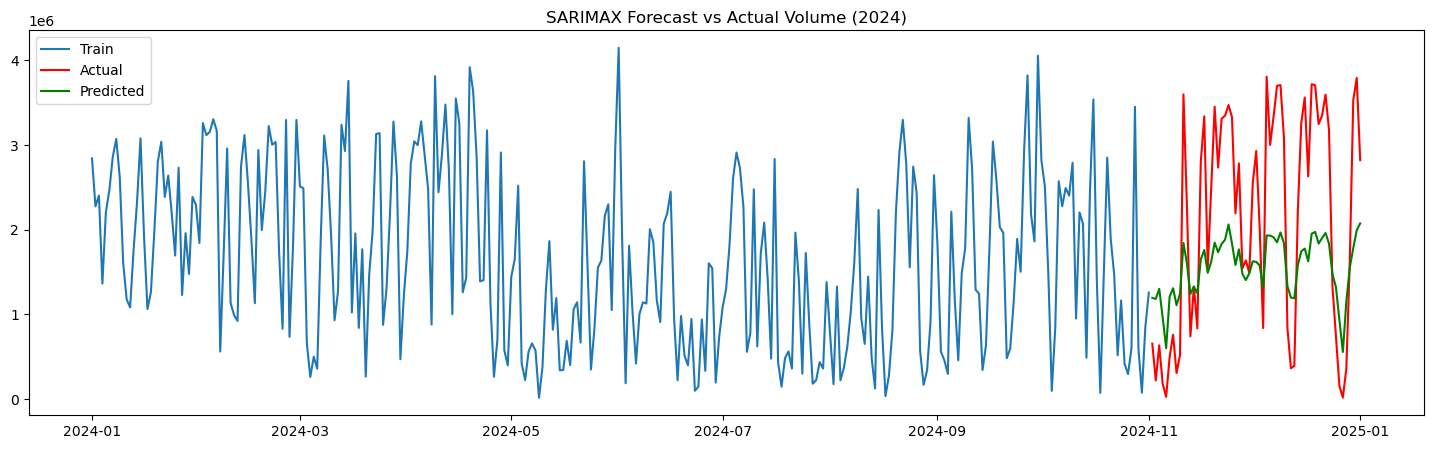

In [217]:
# Plot predictions
plt.figure(figsize=(18,5))

# Filter 2024 data
train_subset = train_db_d_off[train_db_d_off.index >= "2024-01-01"]
test_subset = test_db_d_off[test_db_d_off.index >= "2024-01-01"]
pred_subset = predictions[predictions.index >= "2024-01-01"]

plt.plot(train_subset['volume'], label="Train")
plt.plot(test_subset['volume'], label="Actual", color='red')
plt.plot(pred_subset, label="Predicted", color='green')

plt.legend()
plt.title("SARIMAX Forecast vs Actual Volume (2024)")
plt.show()

In [218]:
# Compute MSE and RMSE
mse = mean_squared_error(test_db_d_off['volume'], predictions)
print(f'Mean Squared Error (MSE): {mse:.2f}')
rmse = np.sqrt(mean_squared_error(test_db_d_off['volume'], predictions))
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Squared Error (MSE): 1250433242208.57
Root Mean Squared Error (RMSE): 1118227.72


#### Onshore data

##### Monthly data

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


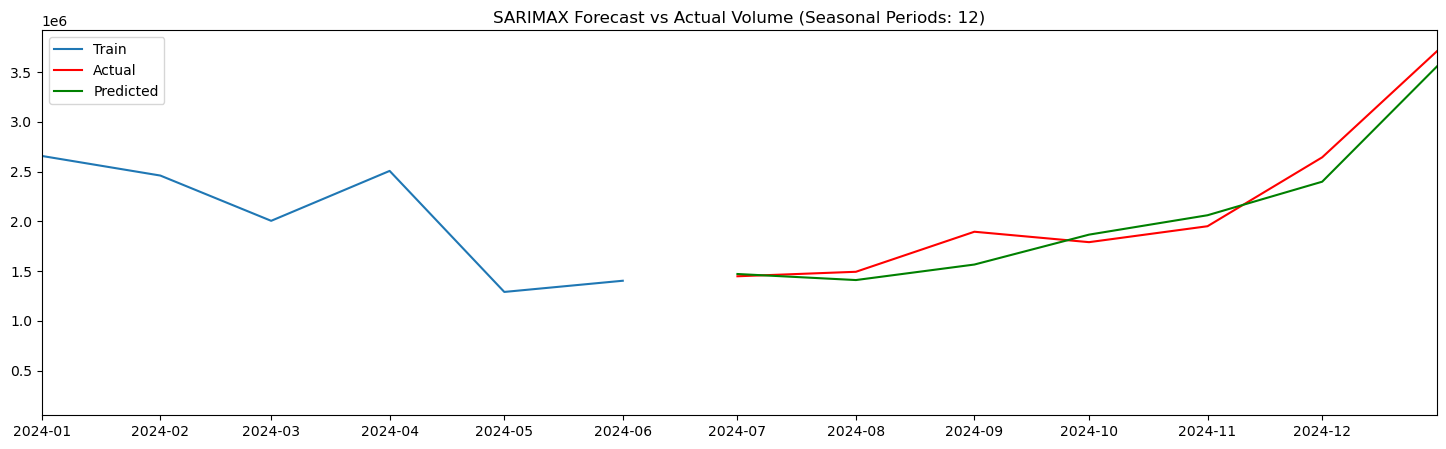

Mean Squared Error (MSE): 30929664072.96
Root Mean Squared Error (RMSE): 175868.31


In [293]:
model_fit_m_on, predictions_m_on, t_stats_m_on = fit_predict_plot_sarimax(
    train_db=train_db_m_on,
    test_db=test_db_m_on,
    target_var='volume',
    exclude_cols=['capacity', 'week_number', 'percentage', 'wind_speed_avg_10'],
    order=(3,1,1),
    seasonal_periods=12
)

##### Weekly data

In [294]:
# Retrieve exogenous variables
exog_vars = train_db_w_on.columns.drop(['volume', 'wind_speed_avg_10', 'percentage', 'capacity'])

# Standartise variables
scaler = StandardScaler()
train_exog_scaled_w = scaler.fit_transform(train_db_w_on[exog_vars])
test_exog_scaled_w = scaler.transform(test_db_w_on[exog_vars])

# Fit the model
model = SARIMAX(
        train_db_w_on['volume'], 
        exog=train_exog_scaled_w,
        order=(3,1,0),  # ARIMA components
        seasonal_order=(1,1,1,52)  # Seasonal components
    )
model_fit = model.fit(disp=True)

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)


In [295]:
exog_coeffs = model_fit.params[model_fit.model.exog_names]
exog_t_stats = exog_coeffs / model_fit.bse[model_fit.model.exog_names]
exog_t_stats.sort_values(ascending=False)

x2    12.976477
x1     1.799837
x3     0.497377
x4    -0.317267
dtype: float64

In [296]:
# Predict
predictions = model_fit.predict(
    start=len(train_db_w_on['volume']), 
    end=len(train_db_w_on['volume']) + len(test_db_w_on['volume']) - 1, 
    exog=test_exog_scaled_w, 
    dynamic=False)

In [297]:
# Compute MSE and RMSE
mse = mean_squared_error(test_db_w_on['volume'], predictions)
print(f'Mean Squared Error (MSE): {mse:.2f}')
rmse = np.sqrt(mean_squared_error(test_db_w_on['volume'], predictions))
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Squared Error (MSE): 671303777519.57
Root Mean Squared Error (RMSE): 819331.30


##### Daily data

In [298]:
# Retrieve exogenous variables
exog_vars = train_db_d_on.columns.drop(['volume', 'wind_speed_avg_10', 'percentage', 'capacity', 'week_number'])

# Standartise variables
scaler = StandardScaler()
train_exog_scaled_d = scaler.fit_transform(train_db_d_on[exog_vars])
test_exog_scaled_d = scaler.transform(test_db_d_on[exog_vars])

# Alternative approach: 
stl = STL(train_db_d_on['volume'], period=365)
result = stl.fit()
train_db_d_on['deseasonalized'] = train_db_d_on['volume'] - result.seasonal

# Now apply SARIMA to deseasonalized data
model = SARIMAX(
        train_db_d_on['deseasonalized'], 
        exog=train_exog_scaled_d,
        order=(3,1,0),
        seasonal_order=(1,1,1,30)
  )  # Use a smaller seasonal period like 30 (monthly) if needed

model_fit = model.fit(disp=True)

/var/folders/6x/v5640c0d6tjd96p_48y5_sy40000gn/T/ipykernel_5199/253699471.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_db_d_on['deseasonalized'] = train_db_d_on['volume'] - result.seasonal
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [299]:
exog_coeffs = model_fit.params[model_fit.model.exog_names]
exog_t_stats = exog_coeffs / model_fit.bse[model_fit.model.exog_names]
exog_t_stats.sort_values(ascending=False)

x2    19.308788
x1     0.198366
x3    -0.000283
x4    -0.424979
dtype: float64

In [300]:
# Predict 
predictions = model_fit.predict(
    start=len(train_db_d_on['volume']), 
    end=len(train_db_d_on['volume']) + len(test_db_d_on['volume']) - 1, 
    exog=test_exog_scaled_d, 
    dynamic=False)

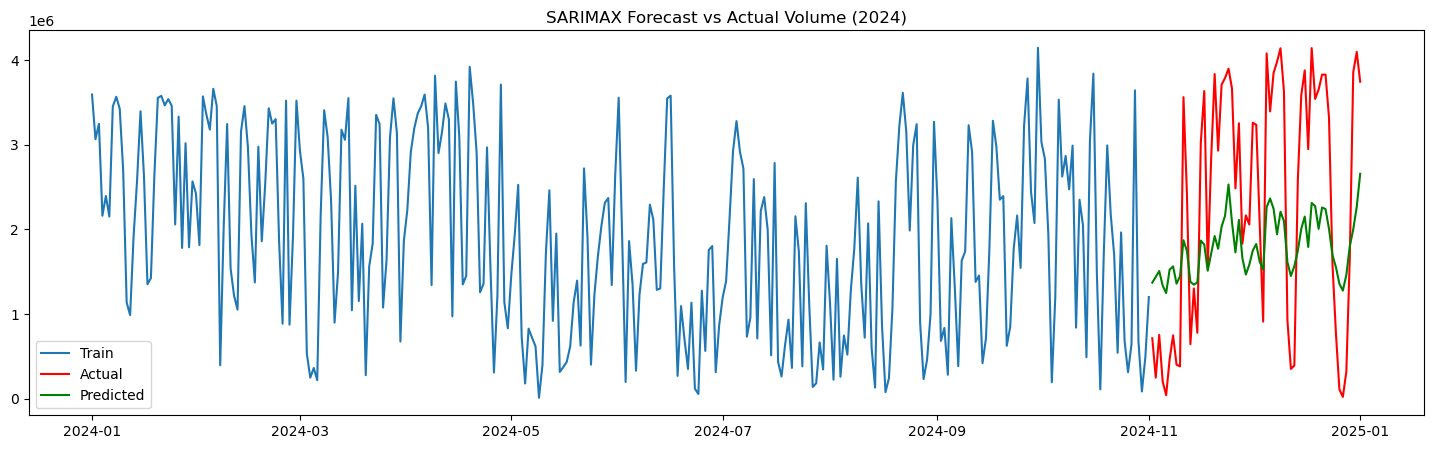

In [301]:
# Plot predictions
plt.figure(figsize=(18,5))

# Filter 2024 data
train_subset = train_db_d_on[train_db_d_on.index >= "2024-01-01"]
test_subset = test_db_d_on[test_db_d_on.index >= "2024-01-01"]
pred_subset = predictions[predictions.index >= "2024-01-01"]

plt.plot(train_subset['volume'], label="Train")
plt.plot(test_subset['volume'], label="Actual", color='red')
plt.plot(pred_subset, label="Predicted", color='green')

plt.legend()
plt.title("SARIMAX Forecast vs Actual Volume (2024)")
plt.show()

In [302]:
# Compute MSE and RMSE
mse = mean_squared_error(test_db_d_on['volume'], predictions)
print(f'Mean Squared Error (MSE): {mse:.2f}')
rmse = np.sqrt(mean_squared_error(test_db_d_on['volume'], predictions))
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Squared Error (MSE): 1583201071401.17
Root Mean Squared Error (RMSE): 1258253.18
